In [1]:
import argparse
from pathlib import Path

import numpy as np
import pandas as pd
import SimpleITK as sitk
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
from scipy import optimize

from skimage import io as skio
from skimage.color import rgb2gray, rgb2hed
from skimage.filters import gaussian, median, sobel, frangi, threshold_otsu
from skimage.feature import structure_tensor
from skimage.measure import label, regionprops_table
from skimage.morphology import disk, remove_small_objects
from skimage.restoration import denoise_nl_means, estimate_sigma
from skimage.transform import resize
from sklearn.decomposition import NMF
from sklearn.neighbors import NearestNeighbors
from pyimzml.ImzMLParser import ImzMLParser, getionimage

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cv2
from pathlib import Path
from scipy.interpolate import RBFInterpolator
from scipy.optimize import minimize
from skimage import transform, filters
try:
    import SimpleITK as sitk
    SITK_AVAILABLE = True
except ImportError:
    SITK_AVAILABLE = False
    print("WARNING: SimpleITK not installed. B-spline registration unavailable.")
    print("Install with: pip install SimpleITK")
from pyimzml.ImzMLParser import ImzMLParser
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import pandas as pd
import warnings
warnings.filterwarnings('ignore')


save the image in the exact dimensions given 

checking to see if the initial alignment gives us a reasonable coordinate structure 

# Fine Scale Alignment

Got the initial transform done with the correct cropped region 

In [2]:

def dbscan_1d_ish(imzml_path: str, mz_tol: float, min_intensity: float, min_count: int) -> pd.DataFrame:
    """
    Perform DBSCAN-like clustering on the m/z values in the dataframe. Clusters for now
    will be defined as contiguous regions where the difference between adjacent m/z values is less than mz_tol.
    Clusters with fewer than min_count points will be flagged as "noise".

    :param mz_tol: the tolerance for the m/z values
    :param min_intensity: the minimum intensity for a m/z to be considered
    :param min_count: the minimum number of points to form a cluster

    :return: a DataFrame with additional columns for delta_mz, in_dense_region, and cluster_labels
    :rtype: pandas.DataFrame
    """
    parser = ImzMLParser(imzml_path)
    df =pd.DataFrame(
                (   # neat trick to unpack the mzs and intensities directly into the row
                    # * is a unpacking operator called splat and it unpacks the tuple of mzs and intensities
                    # from getspectrum into individual elements in the new tuple
                    (*parser.getspectrum(idx), (x,y)) for idx, (x,y,_) in enumerate(parser.coordinates)
                ),
                    columns=["mzs", "intensities", "coordinates"]
        )
    # pull raw arrays out of the dataframe — no copies yet
    mzs_arr    = df['mzs'].to_numpy()
    intens_arr = df['intensities'].to_numpy()
    coords_arr = df['coordinates'].to_numpy()

    # single-pass concatenation — much faster than explode
    all_mzs    = np.concatenate(mzs_arr).astype(np.float32)
    all_intens = np.concatenate(intens_arr).astype(np.float32)
    lengths    = np.fromiter((len(a) for a in mzs_arr), dtype=np.int32, count=len(mzs_arr))
    all_coords = np.repeat(coords_arr, lengths)

    # filter BEFORE building the dataframe — avoids allocating rows you'll discard
    mask       = all_intens > min_intensity
    all_mzs    = all_mzs[mask]
    all_intens = all_intens[mask]
    all_coords = all_coords[mask]

    # sort on numpy arrays — faster than df.sort_values + reset_index
    print(f"Sorting m/z values...{mask.sum()} values")
    order      = np.argsort(all_mzs, kind='stable')

    print(f"building long_df")
    long_df = pd.DataFrame({
        'mzs':         all_mzs[order],
        'intensities': all_intens[order],
        'coordinates': all_coords[order],
    })

    
    print(f'\nlong_df columns: {long_df.columns}\n')  # print the columns of long_df.columns)
    
    # check if long
    # find the deltas between adjacent m/z values
    print("calculating deltas")
    delta_values = -1 * long_df['mzs'].values[0:(len(long_df) - min_count)] + long_df['mzs'].values[min_count:(len(long_df) + min_count)]
    
    # 0 padding missing values to match the length of the dataframe
    long_df['delta_mz'] = np.concatenate([delta_values, [0] * min_count])
    del delta_values

    # creating a boolean mask for regions where delta_mz < mz_tol
    long_df['in_dense_region'] = (long_df['delta_mz'] < mz_tol).astype(int)

    # Calculating difference of boolean flags
    # Calculate diff without fillna to get proper length n-1
    difference = np.diff(long_df['in_dense_region'].values)
    difference_plus = np.maximum(difference, 0)
    running_clusternr = np.cumsum(difference_plus)
    del difference
    del difference_plus

    # intermediate vector of of boolean flags
    delta = long_df['in_dense_region'].values

    # Now both have compatible shapes: delta[:-1] and running_clusternr are both length n-1
    clusternr = delta[:-1] * running_clusternr
    del running_clusternr

    # 0 padding missing values to match the length of the dataframe
    long_df['cluster_labels'] = np.concatenate([[delta[0]], clusternr])
    del clusternr
    del delta

    # Remove noise clusters
    # going to prune the data
    long_df = long_df[long_df["cluster_labels"] != 0]

    # Remove clusters with fewer than N mz values
    long_df = long_df[long_df.groupby('cluster_labels') ['mzs'].transform('size') >= min_count]

    import scipy.sparse as sp

    # grouping mzs based on the median of the cluster labels, and summing the intensities for each coordinate and mz_label pair
    print("Grouping m/z values and summing intensities...")
    grouped = (
        long_df
        .assign(mz_label=long_df.groupby('cluster_labels')['mzs'].transform('median'))
        .groupby(['coordinates', 'mz_label'])['intensities']
        .sum()
    )

    # Build integer codes for rows (coordinates) and cols (mz_label)
    print("Getting the coordinate and mz labels")
    coord_idx, coord_labels = pd.factorize(grouped.index.get_level_values('coordinates'))
    mz_idx,    mz_labels    = pd.factorize(grouped.index.get_level_values('mz_label'))
    
    # making it sparse to save memory
    print("Generating spot x feature matrix (sparse)...")
    spot_feature_matrix = sp.csr_matrix(
        (grouped.values, (coord_idx, mz_idx)),
        shape=(len(coord_labels), len(mz_labels))
    )


    return spot_feature_matrix, coord_labels, mz_labels


In [3]:
imzml_path = "/home/kia/MALDI_Metabolomics/metabol_data/20251012_old_liver.imzML"
spot_feature_matrix, coord_labels, mz_labels = dbscan_1d_ish(imzml_path, mz_tol=0.0042, min_intensity=5, min_count=25)

Sorting m/z values...39694844 values
building long_df

long_df columns: Index(['mzs', 'intensities', 'coordinates'], dtype='object')

calculating deltas
Grouping m/z values and summing intensities...
Getting the coordinate and mz labels
Generating spot x feature matrix (sparse)...


Loading images for registration 

In [4]:
import skimage

# then we get our sinusoid mask from the H&E image called S_HE in the manuscript
cropped_img = skimage.io.imread('/home/kia/MALDI_Metabolomics/metabol_data/high_res_MSI/he_cropped.tif')
he_img = skimage.io.imread('/home/kia/MALDI_Metabolomics/metabol_data/high_res_MSI/D2_10x_originalExport.tif')
maldi_img = skimage.io.imread('/home/kia/MALDI_Metabolomics/metabol_data/maldi_moving_img.png')

In [5]:
maldi_coord_map = pd.read_csv('/home/kia/MALDI_Metabolomics/metabol_data/space_ranger_segmented_outputs/cell_segmentations_out3_pixel_warp_affine_vs_tps.csv')

# Align by native MSI pixel identity (msi_x, msi_y) rather than assuming the
# CSV's row order matches spot_feature_matrix's row order. pandas.groupby
# (used to build coord_labels in dbscan_1d_ish) sorts its keys by default,
# so coord_labels is NOT in the CSV's original row order — using positional
# alignment here would silently pair every MSI feature row with the wrong
# H&E-space coordinate.
msi_to_he = dict(zip(
    zip(maldi_coord_map['msi_x'].astype(float), maldi_coord_map['msi_y'].astype(float)),
    zip(maldi_coord_map['he_x_tps'], maldi_coord_map['he_y_tps'])
))
T0_maldi_coords = np.array([msi_to_he[(float(x), float(y))] for x, y in coord_labels])

xs = T0_maldi_coords[:, 0]
ys = T0_maldi_coords[:, 1]

x_min, x_max = int(xs.min()), int(xs.max()) + 1
y_min, y_max = int(ys.min()), int(ys.max()) + 1

### Alternative T0: manual fiducial landmark registration (new methods, Sec. 1)

Replaces the `T1_finescale.csv` load above -- picks landmarks with OpenCV, fits affine + non-optimized TPS with SimpleITK/scipy, and overwrites `T0_maldi_coords`. Run this cell group instead of (or after) the CSV load above to regenerate T0 from scratch.

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def pick_landmarks_matplotlib(he_image, maldi_image, n_points):
    print(f"\n{'='*60}\nLANDMARK SELECTION -- click {n_points} vessel pairs\n{'='*60}")
    
    if type(he_image) == sitk.Image:
        print('SimpleITK image format...changing to numpy array')
        he_image = sitk.GetArrayFromImage(he_image)
        maldi_image = sitk.GetArrayFromImage(maldi_image) 

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    ax1.imshow(he_image);    ax1.set_title("H&E -- FIRST",   fontweight="bold"); ax1.axis("off")
    ax2.imshow(maldi_image); ax2.set_title("MALDI -- SECOND", fontweight="bold"); ax2.axis("off")

    he_pts, maldi_pts, current = [], [], ["he"]

    def onclick(event):
        if event.inaxes is None:
            return
        x, y = event.xdata, event.ydata

        if event.inaxes == ax1 and current[0] == "he":
            if len(he_pts) < n_points:
                he_pts.append([x, y])
                i = len(he_pts)
                ax1.plot(x, y, "ro", markersize=10, markeredgecolor="white", markeredgewidth=2)
                ax1.text(x, y, str(i), color="yellow", fontsize=11, fontweight="bold", ha="center", va="center")
                print(f"H&E landmark {i}/{n_points}: ({x:.1f}, {y:.1f})")
            if len(he_pts) == n_points:
                current[0] = "maldi"
                ax2.set_title("MALDI -- CLICK NOW", fontweight="bold", color="red")
                fig.canvas.draw_idle()

        elif event.inaxes == ax2 and current[0] == "maldi":
            if len(maldi_pts) < n_points:
                maldi_pts.append([x, y])
                i = len(maldi_pts)
                ax2.plot(x, y, "ro", markersize=10, markeredgecolor="white", markeredgewidth=2)
                ax2.text(x, y, str(i), color="yellow", fontsize=11, fontweight="bold", ha="center", va="center")
                print(f"MALDI landmark {i}/{n_points}: ({x:.1f}, {y:.1f})")
            if len(maldi_pts) == n_points:
                ax2.set_title("MALDI -- COMPLETE! Close window.", fontweight="bold", color="green")
                fig.canvas.mpl_disconnect(cid)
                fig.canvas.draw()
                plt.close(fig)  # unblocks plt.show(block=True)
                return

        fig.canvas.draw_idle()

    cid = fig.canvas.mpl_connect("button_press_event", onclick)
    plt.tight_layout()
    plt.show(block=True)  # blocks here until all landmarks are picked

    print("Landmark selection complete.")
    return np.array(he_pts, dtype=float), np.array(maldi_pts, dtype=float)

In [7]:
landmarks = pd.read_csv('/home/kia/MALDI_Metabolomics/notebooks/fiducial_landmarks_nuclei.csv')
landmarks 

,he_x,he_y,msi_x,msi_y
0,7626.0,4270.0,98.703722,109.111646
1,7332.0,4964.0,54.441450,210.560314
2,7092.0,4860.0,14.639718,190.316330
3,8416.0,4096.0,220.625120,76.515399
4,8366.0,5728.0,208.272859,327.563683
5,8820.0,6470.0,273.694097,442.737087
6,9510.0,7002.0,380.175168,523.369907
7,10406.0,7590.0,514.105711,616.354989
8,11322.0,6870.0,657.986686,509.873917
9,10910.0,5894.0,595.081649,361.646776


In [8]:
he_landmarks = landmarks[['he_x', 'he_y']].to_numpy()
maldi_landmarks = landmarks[['msi_x', 'msi_y']].to_numpy()

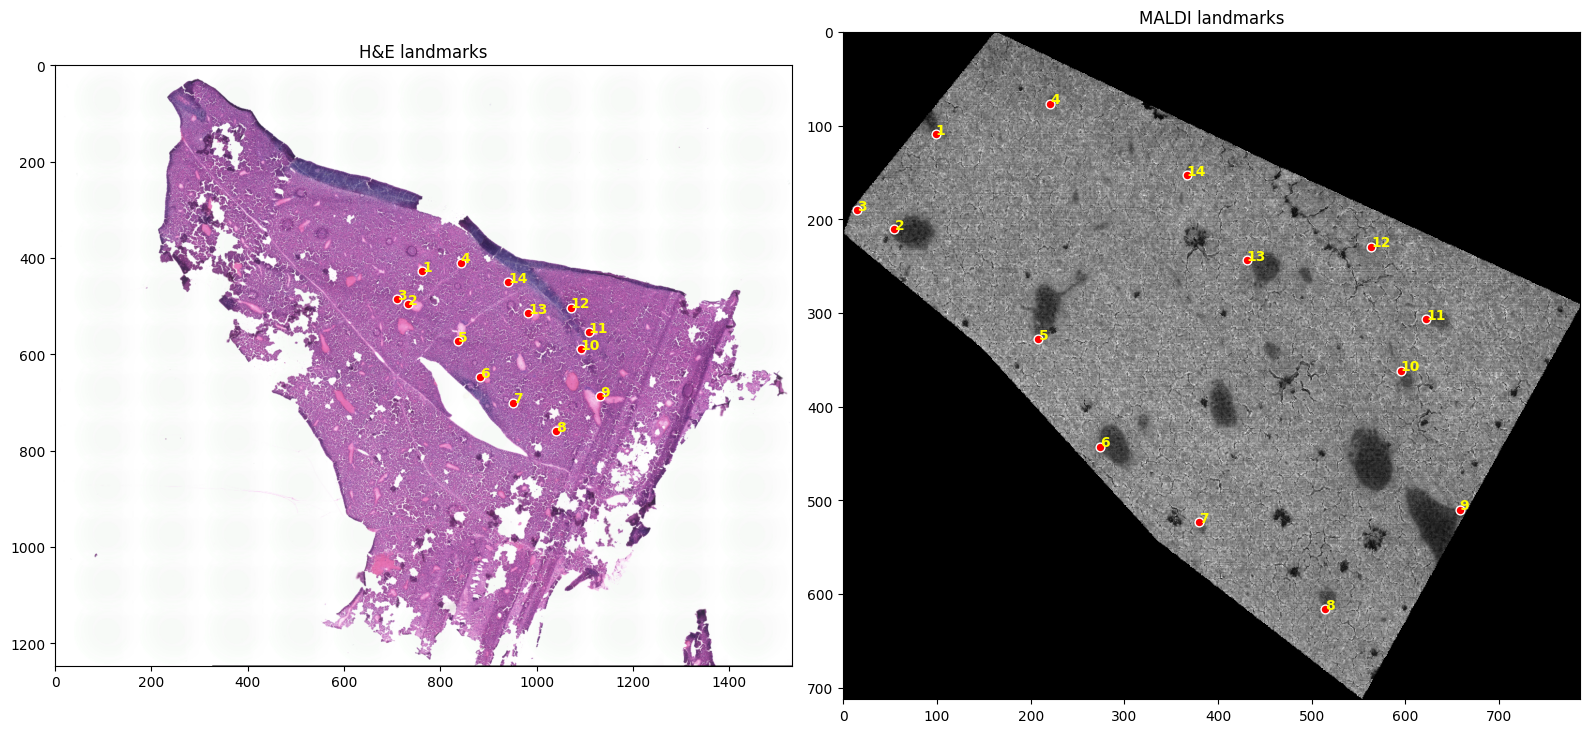

In [9]:
# QC: visualize the currently-saved landmarks without re-picking
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

he_scale_plot = 0.1
he_small = cv2.resize(he_img, None, fx=he_scale_plot, fy=he_scale_plot)
axes[0].imshow(he_small)
axes[0].scatter(he_landmarks[:, 0] * he_scale_plot, he_landmarks[:, 1] * he_scale_plot,
                 c="red", s=40, edgecolors="white")
for i, p in enumerate(he_landmarks):
    axes[0].annotate(str(i + 1), p * he_scale_plot, color="yellow", fontsize=10, fontweight="bold")
axes[0].set_title("H&E landmarks")

axes[1].imshow(maldi_img, cmap="gray")
axes[1].scatter(maldi_landmarks[:, 0], maldi_landmarks[:, 1], c="red", s=40, edgecolors="white")
for i, p in enumerate(maldi_landmarks):
    axes[1].annotate(str(i + 1), p, color="yellow", fontsize=10, fontweight="bold")
axes[1].set_title("MALDI landmarks")

plt.tight_layout()
plt.show()


In [10]:
T0_coord_map = pd.read_csv('/home/kia/MALDI_Metabolomics/notebooks/T1_finescale.csv')
T0_maldi_coords = T0_coord_map[['X', 'Y']].to_numpy()

2026-08-07 10:58:37.707688: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-07 10:58:37.738603: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-08-07 10:58:38.997189: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Found model '2D_versatile_he' for 'StarDist2D'.


I0000 00:00:1786093121.409551   28318 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6123 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.692478, nms_thresh=0.3.
effective: block_size=(2048, 2048, 3), min_overlap=(128, 128, 0), context=(128, 128, 0)


2026-08-07 10:58:42.851975: I external/local_xla/xla/service/service.cc:163] XLA service 0x748b8800d070 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-08-07 10:58:42.851995: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4070 Laptop GPU, Compute Capability 8.9
2026-08-07 10:58:42.877121: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-08-07 10:58:42.953696: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
I0000 00:00:1786093124.247788   28559 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
  0%|          | 0/9 [00:00<?, ?it/s]2026-08-07 10:58:45.254729: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal a

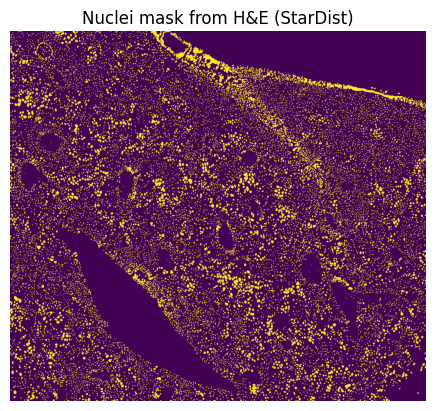

In [11]:
from stardist.models import StarDist2D
from csbdeep.utils import normalize

def compute_nuclei_mask_stardist(he_img, model=None, block_size=2048, min_overlap=128, context=128, 
                                 prob_thresh=0.3, nms_thresh=0.8):
    """
    Nuclei mask via StarDist's pretrained H&E model, instead of a plain
    Otsu threshold + size filter. StarDist gives per-nucleus instance
    labels (properly separating touching nuclei, real learned shape
    boundaries), which we binarize. predict_instances_big tiles the image
    internally since cropped_img is too large for a single forward pass.
    """
    if model is None:
        model = StarDist2D.from_pretrained('2D_versatile_he')

    img_norm = normalize(he_img)
    labels, _ = model.predict_instances_big(
        img_norm, axes='YXC',
        block_size=block_size, 
        min_overlap=min_overlap, 
        context=context,
        prob_thresh=prob_thresh,        # Much lower to catch more nuclei
        nms_thresh=nms_thresh,
    )
    return (labels > 0).astype(np.float32)

nuclei_mask_stardist_crop = compute_nuclei_mask_stardist(cropped_img)

plt.imshow(nuclei_mask_stardist_crop)
plt.title("Nuclei mask from H&E (StarDist)")
plt.axis("off")
plt.show()

In [12]:
# embed into a full-H&E-sized canvas, matching M's shape (paper Sec. 2.1
# convention) -- compute_nuclei_mask_stardist only sees the cropped region
nuclei_mask_stardist = np.zeros(he_img.shape[:2], dtype=np.float32)
nuclei_mask_stardist[y_min:y_max, x_min:x_max] = nuclei_mask_stardist_crop

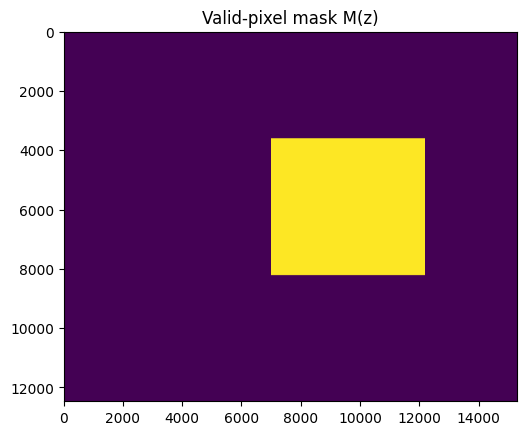

In [13]:
def build_valid_pixel_mask(full_shape, y_min, y_max, x_min, x_max):
    """
    Valid-pixel mask M(z) for the H&E image (paper Sec. 2.1).

    S_HE_full is zero everywhere outside the cropped tissue bounding box
    [y_min:y_max, x_min:x_max] — that's padding, not "no sinusoid here".
    M marks the region where S_HE_full actually carries information, so the
    Wendland convolution can be locally re-normalized instead of treating
    the padded border as real background.
    """
    M = np.zeros(full_shape[:2], dtype=np.float32)
    M[y_min:y_max, x_min:x_max] = 1.0
    return M

M = build_valid_pixel_mask(he_img.shape, y_min, y_max, x_min, x_max)

plt.imshow(M)
plt.title("Valid-pixel mask M(z)")
plt.show()

In [14]:
from sklearn.neighbors import NearestNeighbors

# get the nearest neighbors of the T0_maldi_coords and the distance between these points
neigh = NearestNeighbors(n_neighbors=2)
neigh.fit(T0_maldi_coords)
distances, _ = neigh.kneighbors(T0_maldi_coords)
d_MSI = np.median(distances[:, 1])

# Wendland support radius (paper Sec. 2.2): rho = (sqrt(2)/2) * median(...)
# -- no safety-factor margin, unlike the old paper's (1+eta) version
rho = d_MSI / np.sqrt(2)
h = rho ** 2
r = d_MSI  # kept for any downstream reference to the old name


In [15]:
r

np.float64(6.568044404887877)

In [16]:
import numpy as np
from scipy.signal import convolve2d


def _create_wendland_kernel(h):
    """
    Create normalized Wendland C2 kernel.

    h = kernel support parameter
    """

    radius = int(np.ceil(np.sqrt(h)))

    x = np.arange(-radius, radius+1) # x length of kernel (2*radius+1)
    y = np.arange(-radius, radius+1) # y length (same as x)

    X, Y = np.meshgrid(x, y) # building the kernel grid 

    r2 = X**2 + Y**2 # radial area of influence

    kernel = np.zeros_like(r2, dtype=float) # making the kernel with the same shape as r2 but filled with zeros

    inside = r2 < h # boolean mask for the points that are within the cutoff radius h

    kernel[inside] = (
        (1 - r2[inside]/h)**4 *
        (4*r2[inside]/h + 1)
    ) # function for Wendland C2 kernel (determines influence of each pixel based on distance from center)

    # normalize C_h
    kernel /= kernel.sum()

    return kernel



def smooth_HE_mask(S_HE, h):
    """
    Wendland smoothing of binary H&E mask.

    S_HE:
        binary numpy array

    h:
        kernel support parameter
    """

    K_h = _create_wendland_kernel(h)

    S_HE_tilde = convolve2d(
        S_HE,
        K_h,
        mode="same",
        boundary="symm"
    )

    return S_HE_tilde

#S_HE_tilde = smooth_HE_mask(nuclei_mask, h)
#plt.imshow(S_HE_tilde)
#plt.title("Smoothed sinusoid mask from H&E")
#plt.show()

In [17]:
def smooth_mask_normalized(S_HE, M, h):
    """
    Locally-normalized Wendland smoothing (paper Sec. 2.1, eq. for f(z)).

    Plain convolution of S_HE alone treats padding outside the valid H&E
    domain as real "no signal" background, dimming values near the crop
    edge. Instead we also convolve the valid-pixel mask M and divide it
    out, so each output pixel is renormalized by how much *valid* support
    the kernel actually had at that location.
    """
    K_h = _create_wendland_kernel(h)

    # numerator: raw smoothed sinusoid signal
    N = convolve2d(S_HE, K_h, mode="same", boundary="fill", fillvalue=0)

    # denominator: how much of the kernel's support fell inside valid H&E data
    D = convolve2d(M, K_h, mode="same", boundary="fill", fillvalue=0)

    # only defined where the kernel had at least some valid support
    f = np.zeros_like(N, dtype=np.float32)
    valid = D > 0
    f[valid] = N[valid] / D[valid]
    return f

S_smooth = smooth_mask_normalized(nuclei_mask_stardist, M, h)

#plt.imshow(S_smooth)
#plt.title("Boundary-corrected smoothed sinusoid mask f(z)")
#plt.show()

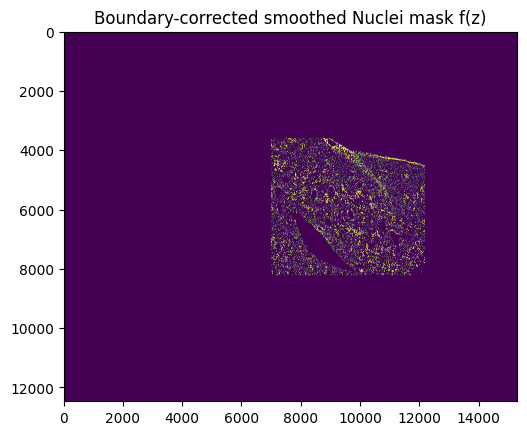

In [18]:
plt.imshow(S_smooth)
plt.title("Boundary-corrected smoothed Nuclei mask f(z)")
plt.show()

In [19]:
from scipy.ndimage import map_coordinates
def project_to_msi(S_smooth, T_U):
    """
    S_smooth: smoothed H&E image
    T_U: (N,2) transformed MSI coordinates in H&E space
    """

    # scipy uses (row, col) = (y, x)
    coords = np.vstack([T_U[:,1], T_U[:,0]])

    values = map_coordinates(
        S_smooth,
        coords,
        order=1,      # bilinear interpolation
        mode='nearest'
    )

    return values


s_T0 shape: (269511,)
s_T0 range: 0.0 to 1.0


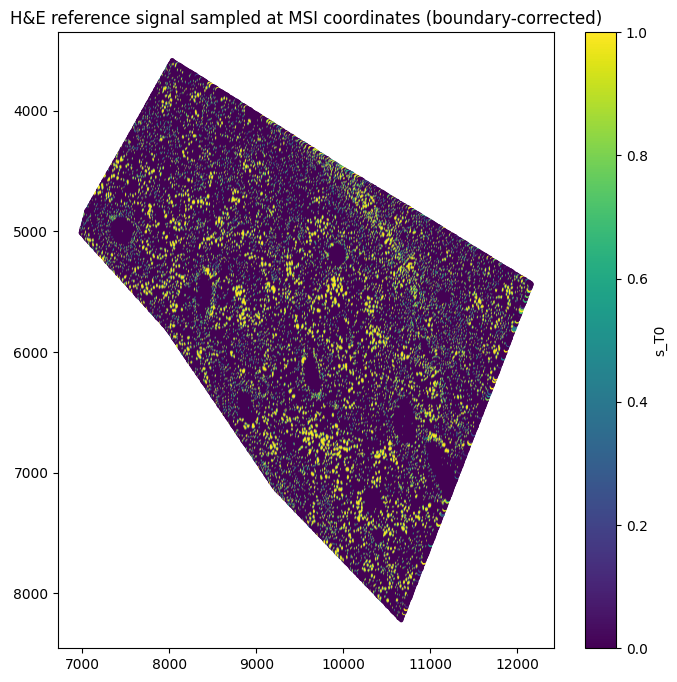

In [20]:
# s_T0(i) = f(T0(u_i)) — sample the boundary-corrected smooth field at each
# MSI pixel's H&E-space coordinate (paper Sec. 1, s_T definition). One row
# per MALDI spot, same order as spot_feature_matrix.
s_T0 = project_to_msi(S_smooth, T0_maldi_coords)

print("s_T0 shape:", s_T0.shape)
print("s_T0 range:", s_T0.min(), "to", s_T0.max())

plt.figure(figsize=(8, 8))
plt.scatter(T0_maldi_coords[:, 0], T0_maldi_coords[:, 1], c=s_T0, s=4, cmap="viridis")
plt.gca().invert_yaxis()
plt.colorbar(label="s_T0")
plt.title("H&E reference signal sampled at MSI coordinates (boundary-corrected)")
plt.savefig('Nuclei_reference_mask_S(HE_nuclei).png')
plt.show()

In [21]:
from typing import List, Tuple

def assign_to_fiducials(
    T0_coords: np.ndarray, fiducials: np.ndarray
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Nearest-fiducial ownership assignment k(i) and distance d_i (paper
    Sec. 2.4): each MSI spot is labelled with the fiducial closest to it,
    partitioning all MSI spots into K per-fiducial "territories". This
    ownership is fixed for all candidate radii, so training/validation
    sets stay disjoint even when peri-fiducial discs overlap.

    T0_coords: (n, 2) array, T0(u_i) for every MSI spot i.
    fiducials: (K, 2) array, H&E fiducial coordinates h_1, ..., h_K.

    Returns:
        k_i: (n,) int array. k_i[i] is the index (0..K-1) of the fiducial
            nearest to spot i -- i.e. which fiducial "owns" that spot.
        d_i: (n,) float array. d_i[i] is the distance from spot i to its
            owning fiducial, h_{k_i[i]}.
    """
    nn = NearestNeighbors(n_neighbors=1).fit(fiducials)
    d_i, k_i = nn.kneighbors(T0_coords)
    return k_i.ravel(), d_i.ravel()

k_i, d_i = assign_to_fiducials(T0_maldi_coords, he_landmarks)


In [22]:
from scipy.spatial.distance import cdist

def spatially_balanced_splits(
    fiducials: np.ndarray, k_i: np.ndarray, B: int = 10, random_state: int = 0
) -> List[Tuple[np.ndarray, np.ndarray]]:
    """
    B repeated bipartitions of the fiducial set (paper Sec. 2.4). Each
    split is grown one fiducial at a time: the half with the smaller
    current total assigned-MSI-spot mass (m_A vs m_B, ties -> A) gets the
    next fiducial, chosen via the k-means++ D^2 rule -- probability
    proportional to squared distance to the nearest fiducial already in
    that half -- to favour spatial spread within each half.

    fiducials: (K, 2) array, H&E fiducial coordinates h_1, ..., h_K.
    k_i: (n,) int array from assign_to_fiducials -- the owning-fiducial
        label for each MSI spot, used to compute each fiducial's
        territory size m_k.
    B: number of repeated splits to generate.

    Returns:
        splits: list of B (A_b, B_b) tuples. A_b and B_b are int arrays
            of fiducial indices (0..K-1), disjoint and together covering
            all K fiducials -- the two halves of split b.
    """
    K = len(fiducials)
    m_k = np.bincount(k_i, minlength=K)  # m_k[k]: number of MSI spots owned by fiducial k
    rng = np.random.RandomState(random_state)

    splits = []
    for _ in range(B):
        seed = rng.choice(K, size=2, replace=False)
        A, Bh = [seed[0]], [seed[1]]
        S_A, S_B = m_k[seed[0]], m_k[seed[1]]  # running total assigned-spot mass per half
        unassigned = set(range(K)) - {seed[0], seed[1]}

        while unassigned:
            target = A if S_A <= S_B else Bh
            remaining = np.array(list(unassigned))
            d2 = cdist(fiducials[remaining], fiducials[target], "sqeuclidean").min(axis=1)
            probs = d2 / d2.sum() if d2.sum() > 0 else np.ones(len(remaining)) / len(remaining)
            chosen = rng.choice(remaining, p=probs)

            target.append(chosen)
            if target is A:
                S_A += m_k[chosen]
            else:
                S_B += m_k[chosen]
            unassigned.remove(chosen)

        splits.append((np.array(A), np.array(Bh)))
    return splits

splits = spatially_balanced_splits(he_landmarks, k_i, B=10)


#### QC: fiducial territories and split balance

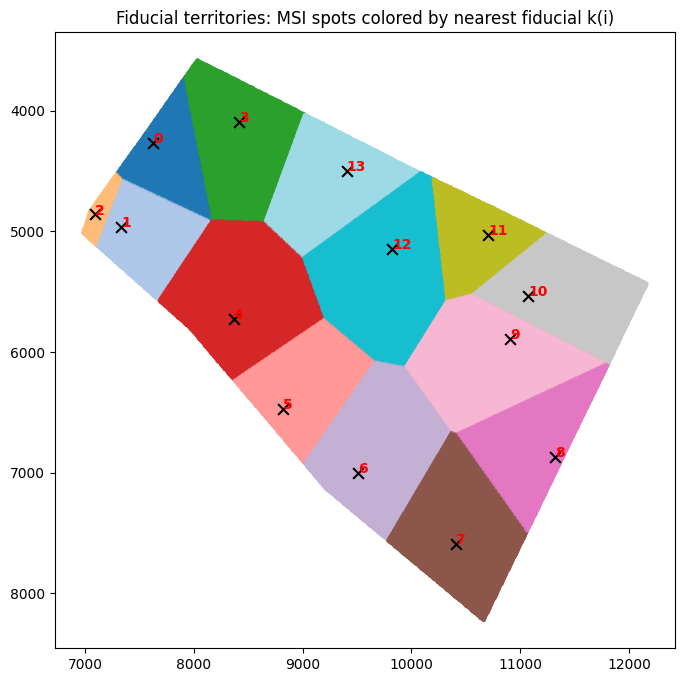

In [23]:
# QC 1: fiducial territories -- confirms k(i) assigns spots to their
# geometrically nearest fiducial in a sane, Voronoi-like pattern
fig, ax = plt.subplots(figsize=(8, 8))
sc = ax.scatter(T0_maldi_coords[:, 0], T0_maldi_coords[:, 1], c=k_i, cmap="tab20", s=3)
ax.scatter(he_landmarks[:, 0], he_landmarks[:, 1], c="k", s=60, marker="x")
for i, p in enumerate(he_landmarks):
    ax.annotate(str(i), p, color="red", fontsize=10, fontweight="bold")
ax.invert_yaxis()
ax.set_title("Fiducial territories: MSI spots colored by nearest fiducial k(i)")
plt.show()


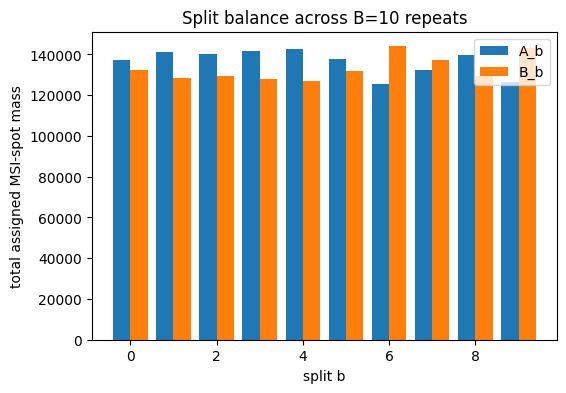

In [24]:
# QC 2: split balance -- confirms S_A and S_B end up close across all
# B=10 splits, i.e. the greedy balancing rule is actually working
S_A_totals = [np.bincount(k_i, minlength=len(he_landmarks))[A].sum() for A, _ in splits]
S_B_totals = [np.bincount(k_i, minlength=len(he_landmarks))[Bh].sum() for _, Bh in splits]

x = np.arange(len(splits))
plt.figure(figsize=(6, 4))
plt.bar(x - 0.2, S_A_totals, width=0.4, label="A_b")
plt.bar(x + 0.2, S_B_totals, width=0.4, label="B_b")
plt.xlabel("split b")
plt.ylabel("total assigned MSI-spot mass")
plt.title("Split balance across B=10 repeats")
plt.legend()
plt.show()


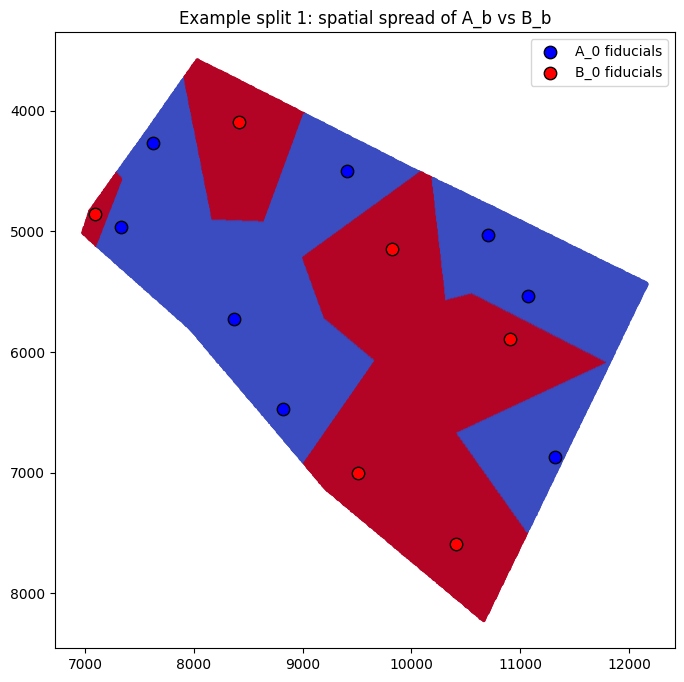

In [25]:
# QC 3: spatial spread of one example split -- confirms the k-means++
# weighting spreads each half across the slide rather than clustering it
A0, B0 = splits[2]
half_label = np.where(np.isin(k_i, A0), 0, 1)

plt.figure(figsize=(8, 8))
plt.scatter(T0_maldi_coords[:, 0], T0_maldi_coords[:, 1], c=half_label, cmap="coolwarm", s=3)
plt.scatter(he_landmarks[A0, 0], he_landmarks[A0, 1], c="blue", edgecolors="k", s=80, label="A_0 fiducials")
plt.scatter(he_landmarks[B0, 0], he_landmarks[B0, 1], c="red", edgecolors="k", s=80, label="B_0 fiducials")
plt.gca().invert_yaxis()
plt.legend()
plt.title("Example split 1: spatial spread of A_b vs B_b")
plt.show()


In [26]:
from sklearn.preprocessing import StandardScaler

def preprocess_features(spot_feature_matrix, low_pct=1, high_pct=99):
    """
    MSI feature preprocessing before ridge fitting (paper Sec. 2.3 requires
    centered/unit-variance features computed once over all valid MSI
    positions, with zero-empirical-variance features removed a priori;
    log transform, TIC normalization, and outlier clipping are standard
    MSI preprocessing added on top of that).
    """
    X = spot_feature_matrix.toarray().astype(np.float32)

    # log transform: raw MS intensities are heavy-tailed/skewed, which can
    # let a few extreme spots dominate both the percentile clip below and
    # the ridge fit itself. log1p handles the many exact-zero entries
    # (no signal for that m/z at that spot) without producing -inf.
    X = np.log1p(X)

    # clip each feature at its 1st/99th percentile so a handful of extreme
    # spots don't dominate the per-column mean/std computed next.
    lo = np.percentile(X, low_pct, axis=0)
    hi = np.percentile(X, high_pct, axis=0)
    X = np.clip(X, lo, hi)

    # drop zero-empirical-variance features (paper Sec. 2.3) before scaling
    keep = X.std(axis=0) > 0
    X = X[:, keep]

    X_scaled = StandardScaler().fit_transform(X)
    return X_scaled, keep

X_scaled, feature_keep_mask = preprocess_features(spot_feature_matrix)
mz_labels = mz_labels[feature_keep_mask]  # keep mz_labels aligned with X_scaled's columns
p = X_scaled.shape[1]


In [27]:
def peri_fiducial_mask(k_i: np.ndarray, d_i: np.ndarray, A: np.ndarray, r: float) -> np.ndarray:
    """I_A(r) as a boolean mask (paper Sec. 2.4): MSI spots owned by a
    fiducial in A, within radius r of their owning fiducial."""
    I_Ar = np.isin(k_i, A) & (d_i <= r)
    return I_Ar


def radius_is_valid(
    r: float, splits: List[Tuple[np.ndarray, np.ndarray]],
    k_i: np.ndarray, d_i: np.ndarray, s_T0: np.ndarray, p: int, v_all: float,
) -> bool:
    """
    Checks n_A(r) >= 2p and v_A(r) >= 0.5*v_all (paper Sec. 2.4) for BOTH
    halves of EVERY split -- both act as a training half in the
    two-directional held-out evaluation in Sec. 2.5.
    """
    for A_b, B_b in splits:
        for A in (A_b, B_b):
            mask = peri_fiducial_mask(k_i, d_i, A, r)
            if mask.sum() < 2 * p or np.var(s_T0[mask]) < 0.5 * v_all:
                return False
    return True


def minimum_candidate_radius(
    splits: List[Tuple[np.ndarray, np.ndarray]],
    k_i: np.ndarray, d_i: np.ndarray, s_T0: np.ndarray, p: int,
) -> float:
    """r_min (paper Sec. 2.4): smallest radius satisfying radius_is_valid,
    searched over the empirical distances d_i."""
    v_all = np.var(s_T0)
    for r in np.sort(np.unique(d_i)):
        if radius_is_valid(r, splits, k_i, d_i, s_T0, p, v_all):
            return r
    raise ValueError("no radius satisfies the minimum candidate radius conditions")



In [28]:
r_min = minimum_candidate_radius(splits, k_i, d_i, s_T0, p)
r_max = d_i.max()

# 8 further equally spaced intermediate empirical quantiles of d_i between r_min and r_max
between = d_i[(d_i > r_min) & (d_i < r_max)]
quantile_fracs = np.linspace(0, 1, 10)[1:-1]  # 8 points strictly between 0 and 1
intermediate_radii = np.quantile(between, quantile_fracs)

radius_candidates = np.unique(np.concatenate([[r_min], intermediate_radii, [r_max]]))
radius_candidates

array([  42.01858681,  182.74793802,  262.5433415 ,  328.95543322,
        390.48549549,  452.87975887,  521.62708685,  602.62611802,
        718.19063191, 1090.95624779])

#### QC: candidate radius selection

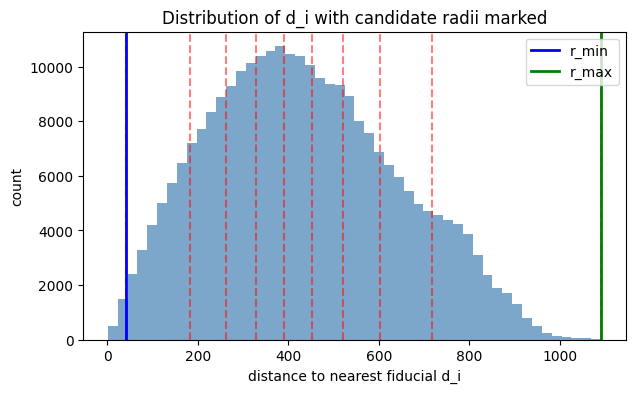

In [29]:
# QC 4: where the candidate radii fall relative to the d_i distribution
plt.figure(figsize=(7, 4))
plt.hist(d_i, bins=50, color="steelblue", alpha=0.7)
for r in radius_candidates:
    plt.axvline(r, color="red", linestyle="--", alpha=0.5)
plt.axvline(r_min, color="blue", linewidth=2, label="r_min")
plt.axvline(r_max, color="green", linewidth=2, label="r_max")
plt.xlabel("distance to nearest fiducial d_i")
plt.ylabel("count")
plt.title("Distribution of d_i with candidate radii marked")
plt.legend()
plt.show()


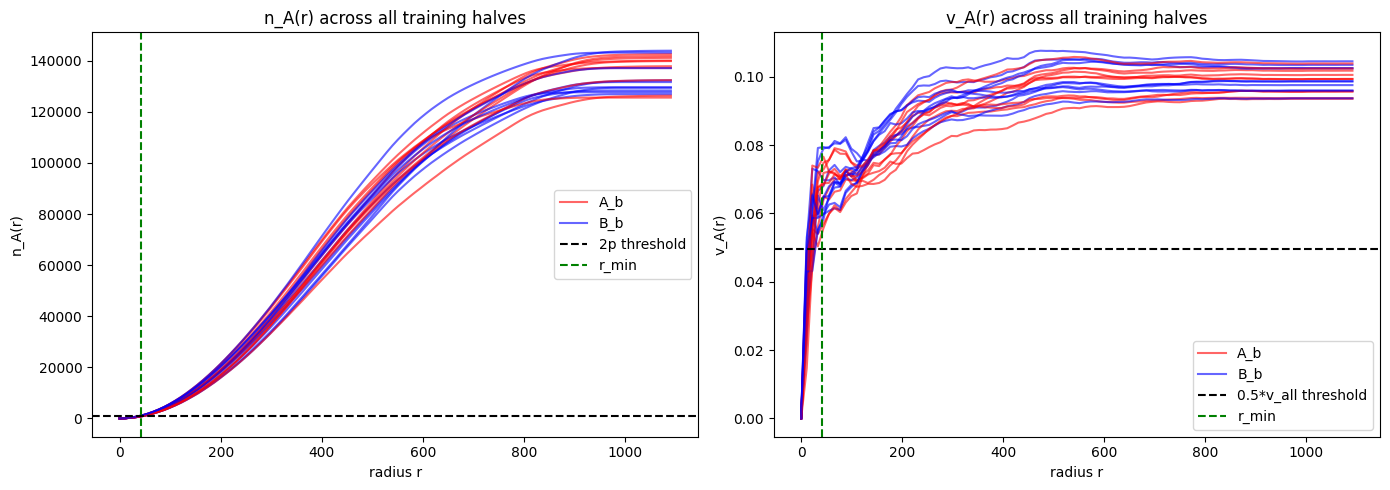

In [30]:
# QC 5: n_A(r) and v_A(r) vs radius, for every training half of every
# split -- A_b curves in red, B_b curves in blue, both dotted, so the plot
# reads as "the A-side vs the B-side" rather than 20 individually tracked lines
v_all = np.var(s_T0)
r_grid = np.linspace(0, r_max, 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for b, (A_b, B_b) in enumerate(splits):
    for A, color, label in [(A_b, "red", "A_b"), (B_b, "blue", "B_b")]:
        n_vals = np.array([peri_fiducial_mask(k_i, d_i, A, r).sum() for r in r_grid])
        v_vals = np.array([
            np.var(s_T0[peri_fiducial_mask(k_i, d_i, A, r)]) if n > 0 else 0
            for r, n in zip(r_grid, n_vals)
        ])
        # only label the first split's curves, so the legend has one A_b/B_b entry each
        plot_label = label if b == 0 else None
        axes[0].plot(r_grid, n_vals, "-", color=color, alpha=0.6, label=plot_label)
        axes[1].plot(r_grid, v_vals, "-", color=color, alpha=0.6, label=plot_label)

axes[0].axhline(2 * p, color="black", linestyle="--", label="2p threshold")
axes[0].axvline(r_min, color="green", linestyle="--", label="r_min")
axes[0].set_xlabel("radius r"); axes[0].set_ylabel("n_A(r)")
axes[0].set_title("n_A(r) across all training halves"); axes[0].legend()

axes[1].axhline(0.5 * v_all, color="black", linestyle="--", label="0.5*v_all threshold")
axes[1].axvline(r_min, color="green", linestyle="--", label="r_min")
axes[1].set_xlabel("radius r"); axes[1].set_ylabel("v_A(r)")
axes[1].set_title("v_A(r) across all training halves"); axes[1].legend()

plt.tight_layout()
plt.show()


In [31]:
from sklearn.linear_model import Ridge
from scipy.stats import pearsonr

def fit_ridge_metafeature(
    X: np.ndarray, s: np.ndarray, index_set: np.ndarray, lam: float = 0.05
) -> np.ndarray:
    """
    Ridge metafeature fit restricted to an index set I (paper Eqs. 1-2,
    Sec. 2.3): unpenalized intercept, fixed lambda=0.05, sign convention
    so the resulting score positively correlates with the target on I.

    sklearn's Ridge loss isn't averaged by n, but the paper's is (1/|I|)
    -- so lam is rescaled to alpha = lam * |I| to match the paper's
    normal equations exactly.

    X: (n, p) standardized MSI feature matrix (all spots).
    s: (n,) H&E-derived target signal, sampled at all spots (e.g. s_T0).
    index_set: indices of the spots this fit is restricted to.

    Returns:
        w_hat: (p,) normalized metafeature direction, Eq. 2.
    """
    X_I, s_I = X[index_set], s[index_set]
    ridge = Ridge(alpha=lam * len(index_set), fit_intercept=True).fit(X_I, s_I)
    beta = ridge.coef_
    w_hat = beta / np.linalg.norm(beta)
    if pearsonr(X_I @ w_hat, s_I)[0] < 0:
        w_hat = -w_hat
    return w_hat


In [32]:
def held_out_radius_score(
    r: float, splits: List[Tuple[np.ndarray, np.ndarray]],
    k_i: np.ndarray, d_i: np.ndarray, X: np.ndarray, s_T0: np.ndarray, lam: float = 0.05,
) -> float:
    """
    C(r) (paper Sec. 2.5): fit a metafeature on one fiducial half's
    peri-fiducial spots, evaluate held-out correlation on the OTHER
    half's territory, in both directions, combined via Fisher-z averaging
    across all B splits.
    """
    Z_bs = []
    for A_b, B_b in splits:
        I_A = np.where(peri_fiducial_mask(k_i, d_i, A_b, r))[0]
        I_B = np.where(peri_fiducial_mask(k_i, d_i, B_b, r))[0]

        w_A = fit_ridge_metafeature(X, s_T0, I_A, lam)
        C_AtoB, _ = pearsonr(X[I_B] @ w_A, s_T0[I_B])

        w_B = fit_ridge_metafeature(X, s_T0, I_B, lam)
        C_BtoA, _ = pearsonr(X[I_A] @ w_B, s_T0[I_A])

        Z_b = 0.5 * (np.arctanh(C_AtoB) + np.arctanh(C_BtoA))
        Z_bs.append(Z_b)

    return np.tanh(np.median(Z_bs))

In [33]:
C_values = np.array([
    held_out_radius_score(r, splits, k_i, d_i, X_scaled, s_T0) for r in radius_candidates
])
C_max = C_values.max()
r_hat = radius_candidates[C_values >= C_max - 0.01].max()

#### QC: held-out radius selection

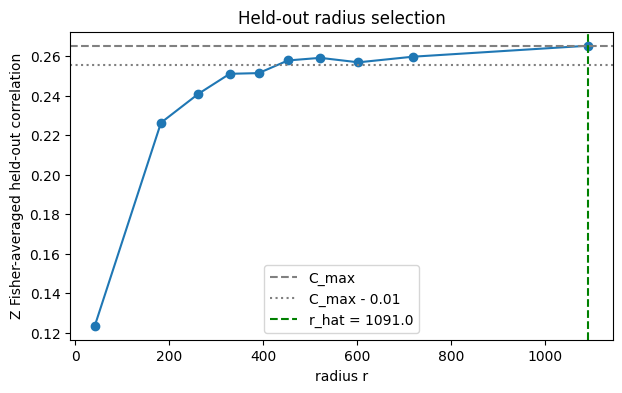

In [34]:
# QC 6: C(r) vs radius, with C_max, the C_max - 0.01 band, and the
# selected r_hat marked
plt.figure(figsize=(7, 4))
plt.plot(radius_candidates, C_values, marker="o")
plt.axhline(C_max, color="gray", linestyle="--", label="C_max")
plt.axhline(C_max - 0.01, color="gray", linestyle=":", label="C_max - 0.01")
plt.axvline(r_hat, color="green", linestyle="--", label=f"r_hat = {r_hat:.1f}")
plt.xlabel("radius r")
plt.ylabel("Z Fisher-averaged held-out correlation")
plt.title("Held-out radius selection")
plt.legend()
plt.show()


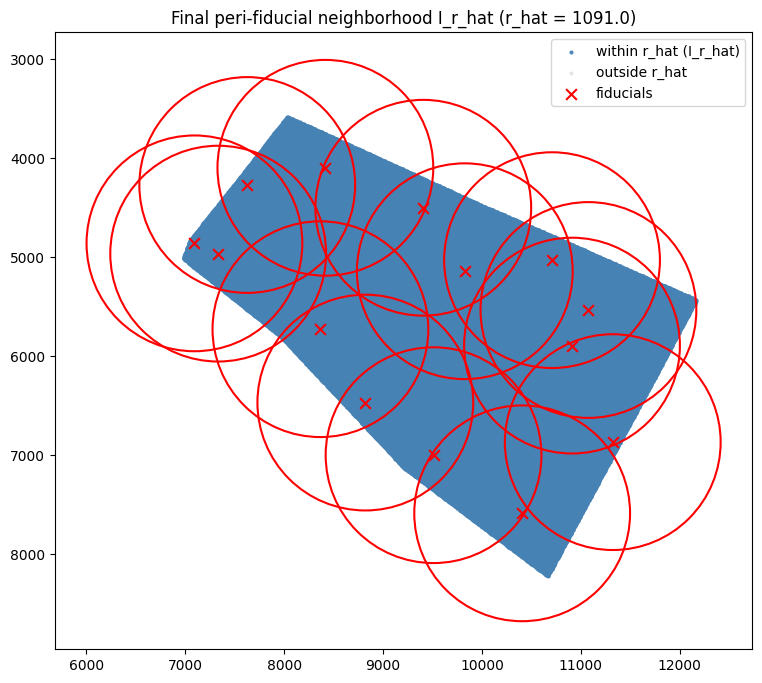

In [35]:
# QC 7: final peri-fiducial neighborhood I_r_hat -- circles of radius
# r_hat drawn around every fiducial, spots inside I_r_hat opaque, spots
# outside faded
in_radius = d_i <= r_hat

fig, ax = plt.subplots(figsize=(9, 9))
ax.scatter(T0_maldi_coords[in_radius, 0], T0_maldi_coords[in_radius, 1],
           c="steelblue", s=4, alpha=0.9, label="within r_hat (I_r_hat)")
ax.scatter(T0_maldi_coords[~in_radius, 0], T0_maldi_coords[~in_radius, 1],
           c="gray", s=4, alpha=0.15, label="outside r_hat")

for landmark in he_landmarks:
    ax.add_patch(plt.Circle(landmark, r_hat, fill=False, edgecolor="red", linewidth=1.5))
ax.scatter(he_landmarks[:, 0], he_landmarks[:, 1], c="red", marker="x", s=60, label="fiducials")

ax.set_aspect("equal")
ax.invert_yaxis()
ax.legend()
ax.set_title(f"Final peri-fiducial neighborhood I_r_hat (r_hat = {r_hat:.1f})")
plt.show()


In [36]:
I_r_hat = np.where(d_i <= r_hat)[0]
w_hat0 = fit_ridge_metafeature(X_scaled, s_T0, I_r_hat, lam=0.05)
q0 = X_scaled @ w_hat0
corr0, _ = pearsonr(q0[I_r_hat], s_T0[I_r_hat])
print(f"corr0 (peri-fiducial, r_hat={r_hat:.1f}): {corr0:.4f}")


corr0 (peri-fiducial, r_hat=1091.0): 0.2774


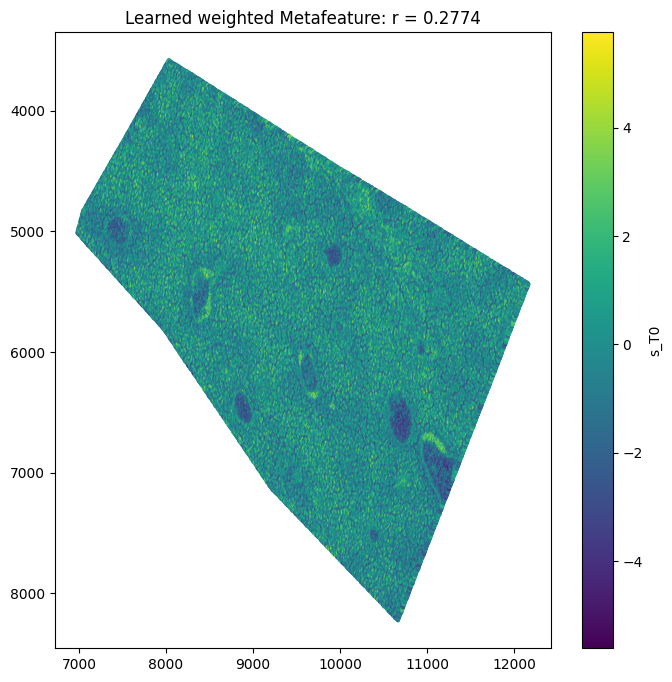

In [37]:
plt.figure(figsize=(8, 8))
plt.scatter(T0_maldi_coords[:, 0], T0_maldi_coords[:, 1], c=q0, s=4, cmap="viridis")
plt.gca().invert_yaxis()
plt.colorbar(label="s_T0")
plt.title(f"Learned weighted Metafeature: r = {corr0:.4f}")
plt.savefig('Learned_Metafeature.png')
plt.show()

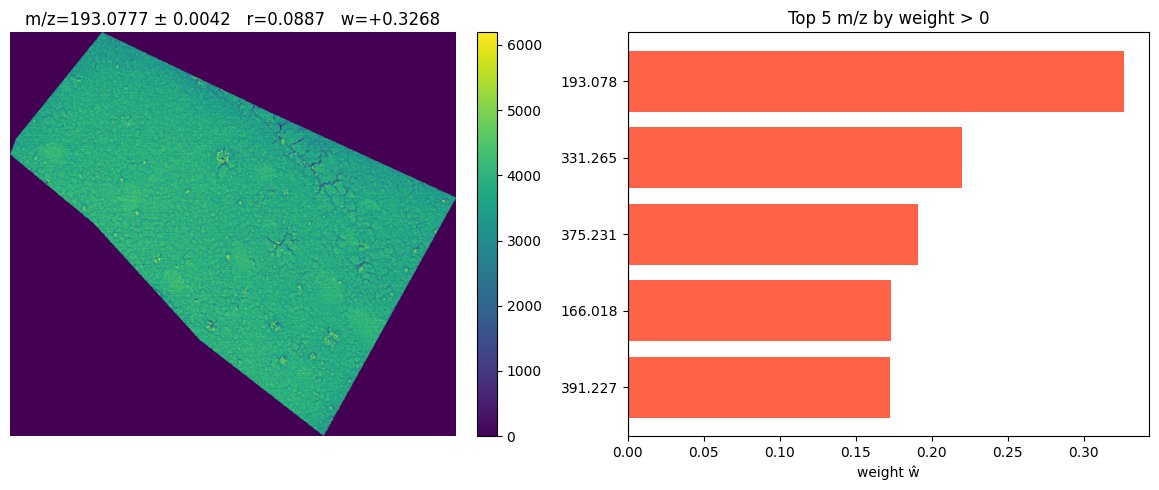

In [38]:
def plot_top_weighted_ion_maps(w_hat, mz_labels, X_scaled, s_scaled, parser, top_n=5, mz_tol=0.0042):
    """
    Diagnostic: ion map of the single top-weighted m/z feature, read
    straight from the raw imzML data via getionimage (left), next to a bar
    chart of the top-n |weight| contributors to the learned metafeature (right).
    """
    #top_idx = np.argsort(np.abs(w_hat))[::-1][:top_n]
    top_idx = np.argsort(w_hat)[::-1][:top_n]
    top_feature_idx = top_idx[0]
    top_mz = mz_labels[top_feature_idx]

    ion_img = getionimage(parser, top_mz, tol=mz_tol)
    r_top, _ = pearsonr(X_scaled[:, top_feature_idx], s_scaled)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    im = axes[0].imshow(ion_img, cmap="viridis")
    axes[0].set_title(f"m/z={top_mz:.4f} ± {mz_tol}   r={r_top:.4f}   w={w_hat[top_feature_idx]:+.4f}")
    axes[0].axis("off")
    fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

    top_mz_str = [f"{mz_labels[i]:.3f}" for i in top_idx[::-1]]
    top_weights = w_hat[top_idx[::-1]]
    axes[1].barh(top_mz_str, top_weights, color=["tomato" if w > 0 else "steelblue" for w in top_weights])
    axes[1].axvline(0, color="k", lw=0.8)
    axes[1].set_xlabel("weight ŵ")
    #axes[1].set_title(f"Top {top_n} m/z by |weight|")
    axes[1].set_title(f"Top {top_n} m/z by weight > 0")
    plt.savefig('Loadings_of_Metafeature.png')
    plt.tight_layout()
    plt.show()
    return top_idx

maldi_parser = ImzMLParser('/home/kia/MALDI_Metabolomics/metabol_data/20251012_old_liver.imzML')
top_idx = plot_top_weighted_ion_maps(w_hat0, mz_labels, X_scaled, s_T0, maldi_parser)

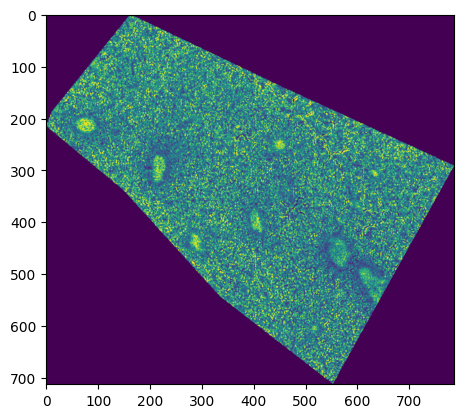

In [39]:
ion_mat = getionimage(maldi_parser,mz_value=166.018, tol=.0042)
plt.imshow(ion_mat, vmin=np.percentile(ion_mat,1), vmax=np.percentile(ion_mat, 99))
#plt.imshow(ion_mat)

In [40]:
def build_control_grid(coords, d_msi, spacing_factor=50, max_dist_factor=1.0):
    """
    Sparse regular grid of TPS control points spanning the MSI footprint
    (paper Sec. 1: Delta^TPS is "parameterised by a sparse set of control
    points"), spaced spacing_factor * d_MSI apart. Grid points that land
    outside the actual tissue footprint (e.g. in the bounding-box corners,
    since the footprint is a rotated blob, not a rectangle) are dropped —
    they'd have no nearby data to inform their displacement anyway.

    The distance cutoff is scaled by d_msi (the data's own pixel spacing),
    not by the control-grid spacing itself — the latter would make the
    cutoff coarser as the grid gets sparser, letting control points sit
    well outside the tissue near irregular/concave boundary regions.
    """
    spacing = spacing_factor * d_msi
    x_min, x_max = coords[:, 0].min(), coords[:, 0].max()
    y_min, y_max = coords[:, 1].min(), coords[:, 1].max()

    n_x = max(2, int(np.ceil((x_max - x_min) / spacing)) + 1)
    n_y = max(2, int(np.ceil((y_max - y_min) / spacing)) + 1)
    cx = np.linspace(x_min, x_max, n_x)
    cy = np.linspace(y_min, y_max, n_y)
    CX, CY = np.meshgrid(cx, cy)
    grid_points = np.column_stack([CX.ravel(), CY.ravel()])

    # drop grid points too far from any actual MSI coordinate, relative to
    # the data's own spacing (not the sparser control-grid spacing)
    neigh = NearestNeighbors(n_neighbors=1).fit(coords)
    dist_to_data, _ = neigh.kneighbors(grid_points)
    control_points = grid_points[dist_to_data.ravel() < max_dist_factor * d_msi]
    return control_points



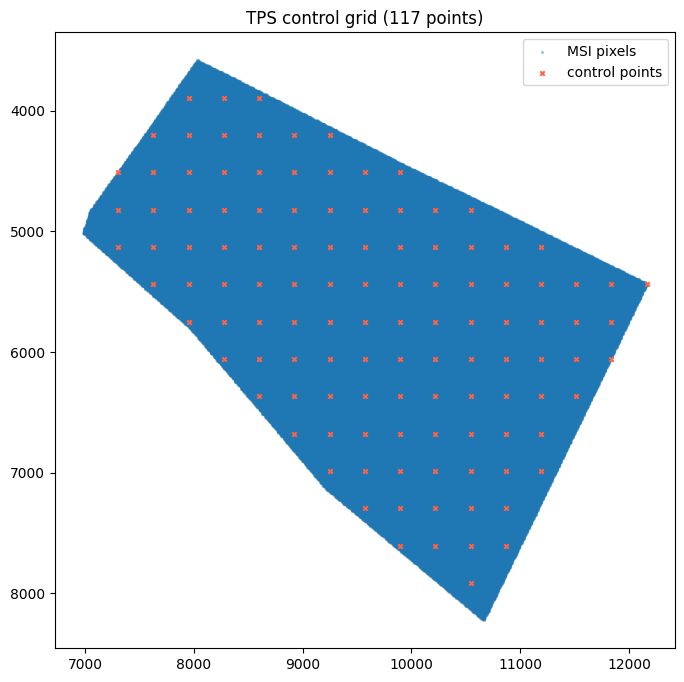

In [41]:
control_points = build_control_grid(T0_maldi_coords, d_MSI)

plt.figure(figsize=(8, 8))
plt.scatter(T0_maldi_coords[:, 0], T0_maldi_coords[:, 1], s=2, alpha=0.3, label="MSI pixels")
plt.scatter(control_points[:, 0], control_points[:, 1], s=10, c="tomato", marker="x", label="control points")
plt.gca().invert_yaxis()
plt.legend()
plt.title(f"TPS control grid ({len(control_points)} points)")
plt.show()

In [42]:
from scipy.spatial.distance import cdist

def tps_kernel(r):
    """Classical TPS radial basis function U(r) = r^2 log(r) (U(0) = 0)."""
    with np.errstate(divide="ignore", invalid="ignore"):
        out = np.where(r > 0, r**2 * np.log(r), 0.0)
    return out

def build_tps_basis(control_points, query_points):
    """
    TPS design matrices (paper Sec. 1/2.3: Delta^TPS parameterised by a
    sparse set of control points; classical TPS bending energy E_bend).
    K: (m,m) kernel between control points, used both to solve for the
       RBF coefficients and to compute the bending energy c^T K c.
    P: (m,3) affine design [1,x,y] at control points; the natural TPS
       boundary condition P^T c = 0 keeps affine motion out of the RBF
       part, so E_bend penalises only non-affine bending.
    Phi, Q: the same bases evaluated at the query points (all MSI
       pixels), used to evaluate the dense displacement field.
    """
    K = tps_kernel(cdist(control_points, control_points))
    P = np.column_stack([np.ones(len(control_points)), control_points])
    Phi = tps_kernel(cdist(query_points, control_points))
    Q = np.column_stack([np.ones(len(query_points)), query_points])
    return K, P, Phi, Q

def solve_tps_coeffs(K, P, targets):
    """
    Solve the standard TPS linear system for one displacement axis:
    [K P; P^T 0] [c; a] = [targets; 0]. Returns RBF coeffs c and affine
    coeffs a.
    """
    m = K.shape[0]
    A = np.block([[K, P], [P.T, np.zeros((3, 3))]])
    rhs = np.concatenate([targets, np.zeros(3)])
    sol = np.linalg.solve(A, rhs)
    return sol[:m], sol[m:]

def evaluate_tps_field(Phi, Q, c, a):
    """Dense displacement values at the query points, given RBF/affine coeffs."""
    return Phi @ c + Q @ a

def tps_bending_energy(K, c_x, c_y):
    """Classical TPS bending energy, summed over the x and y displacement components."""
    return c_x @ K @ c_x + c_y @ K @ c_y

K, P, Phi, Q = build_tps_basis(control_points, T0_maldi_coords)
print("K:", K.shape, " P:", P.shape, " Phi:", Phi.shape, " Q:", Q.shape)

K: (117, 117)  P: (117, 3)  Phi: (269511, 117)  Q: (269511, 3)


In [43]:
def tps_objective(params, K, P, Phi, Q, T0_coords, S_smooth, q, lambda_tps):
    """
    Negative TPS objective (paper Sec. 2.3):
    rho(q, s_T1) - lambda_TPS * E_bend(Delta_TPS), negated for minimize().
    params is the flattened [dx_ctrl; dy_ctrl] control-point displacement
    vector (length 2m); q is the frozen metafeature score from ridge
    fitting, held fixed throughout this optimization.
    """
    m = K.shape[0]
    dx_ctrl, dy_ctrl = params[:m], params[m:]

    # solve each displacement axis's TPS system, then evaluate the dense
    # field at every MSI pixel (reusing the same K/P/Phi/Q basis matrices,
    # which don't change — only the target displacement values do)
    c_x, a_x = solve_tps_coeffs(K, P, dx_ctrl)
    c_y, a_y = solve_tps_coeffs(K, P, dy_ctrl)
    dx = evaluate_tps_field(Phi, Q, c_x, a_x)
    dy = evaluate_tps_field(Phi, Q, c_y, a_y)

    T1_coords = T0_coords + np.column_stack([dx, dy])
    s_T1 = project_to_msi(S_smooth, T1_coords)
    corr, _ = pearsonr(q, s_T1)

    E_bend = tps_bending_energy(K, c_x, c_y)
    return -(corr - lambda_tps * E_bend)

In [44]:
def optimize_tps(K, P, Phi, Q, T0_coords, S_smooth, q, d_msi,
                  lambda_tps, displacement_cap_factor=10, maxiter=100,
                  n_subsample=None, random_state=0):
    """
    Fit TPS control-point displacements by maximizing rho(q, s_T1) -
    lambda_TPS * E_bend (paper Sec. 2.3), via L-BFGS-B. The box bounds
    implement the paper's "loose displacement bounds" -- a generous cap
    (here, a multiple of d_MSI) that should not bind in a well-behaved fit.

    L-BFGS-B's default finite-difference step (~1.49e-8, absolute) is far
    below float32 precision at our coordinate scale (d_MSI ~ 6.5), so the
    numerical gradient underflows to exactly zero and the optimizer
    "converges" at iteration 0 without moving. eps is set to ~1% of
    d_MSI instead -- large enough to register a real change in S_smooth's
    bilinearly-interpolated value, small enough to stay a good local
    derivative estimate.

    n_subsample: if given, evaluate the objective on a random subsample of
    this many MSI pixels instead of all n, for speed -- cost scales with
    n, so this is an independent speedup on top of a sparser control grid.
    Phi/Q/T0_coords/q are all subsampled together (same random rows), so
    each pixel's basis row, position, and target score stay matched up.
    The fitted result is still evaluated on all pixels afterward in
    apply_tps; this only affects what's used *during* optimization.
    """
    m = K.shape[0]
    x0 = np.zeros(2 * m)  # start from T0, i.e. zero residual displacement
    cap = displacement_cap_factor * d_msi
    bounds = [(-cap, cap)] * (2 * m)
    eps = 0.01 * d_msi

    if n_subsample is not None and n_subsample < len(T0_coords):
        rng = np.random.RandomState(random_state)
        sub_idx = rng.choice(len(T0_coords), size=n_subsample, replace=False)
        Phi_use, Q_use, T0_use, q_use = Phi[sub_idx], Q[sub_idx], T0_coords[sub_idx], q[sub_idx]
    else:
        Phi_use, Q_use, T0_use, q_use = Phi, Q, T0_coords, q

    result = minimize(
        tps_objective, x0,
        args=(K, P, Phi_use, Q_use, T0_use, S_smooth, q_use, lambda_tps),
        method="L-BFGS-B",
        bounds=bounds,
        options={"maxiter": maxiter, "disp": True, "eps": eps},
    )
    return result




In [45]:
# timing test first -- see how long a handful of iterations takes before
# committing to a full optimization run
import time
t0 = time.time()
result = optimize_tps(K, P, Phi, Q, T0_maldi_coords, S_smooth, q0, d_MSI, lambda_tps=0.05,maxiter=100, n_subsample=65000)
print(f"elapsed : {time.time() - t0:.1f}s   converged: {result.success}   nit: {result.nit}")

elapsed : 143.0s   converged: True   nit: 22


In [46]:
def apply_tps(result, K, P, Phi, Q, T0_coords):
    """
    Evaluate the fitted TPS control-point displacements over all MSI
    pixels (paper: T1(u_i) = T0(u_i) + Delta^TPS(u_i)). Uses result.x
    regardless of result.success -- it's the best solution found within
    the iteration budget, not garbage if maxiter was hit first.
    """
    m = K.shape[0]
    dx_ctrl, dy_ctrl = result.x[:m], result.x[m:]
    c_x, a_x = solve_tps_coeffs(K, P, dx_ctrl)
    c_y, a_y = solve_tps_coeffs(K, P, dy_ctrl)
    dx = evaluate_tps_field(Phi, Q, c_x, a_x)
    dy = evaluate_tps_field(Phi, Q, c_y, a_y)
    T1_coords = T0_coords + np.column_stack([dx, dy])
    return T1_coords, dx, dy, dx_ctrl, dy_ctrl

stopped because: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
correlation before TPS (T0, full slide): 0.2774   after TPS (T1, full slide): 0.2994


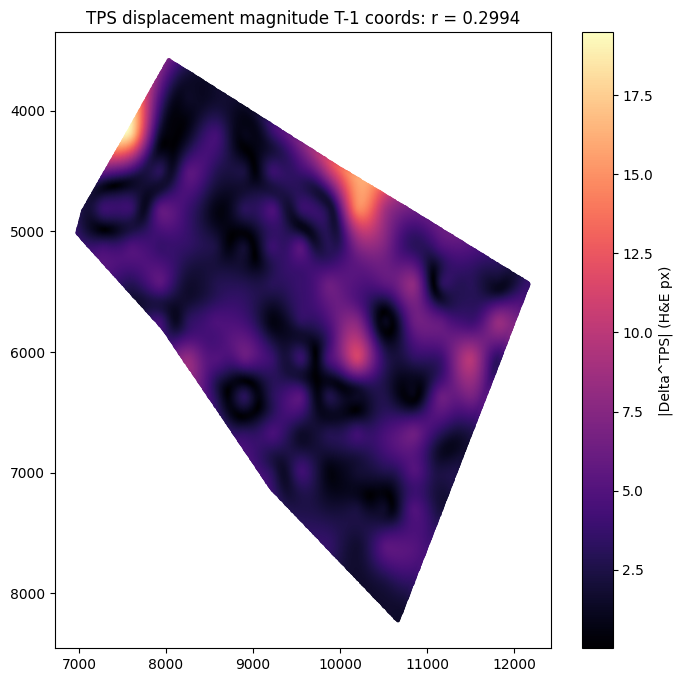

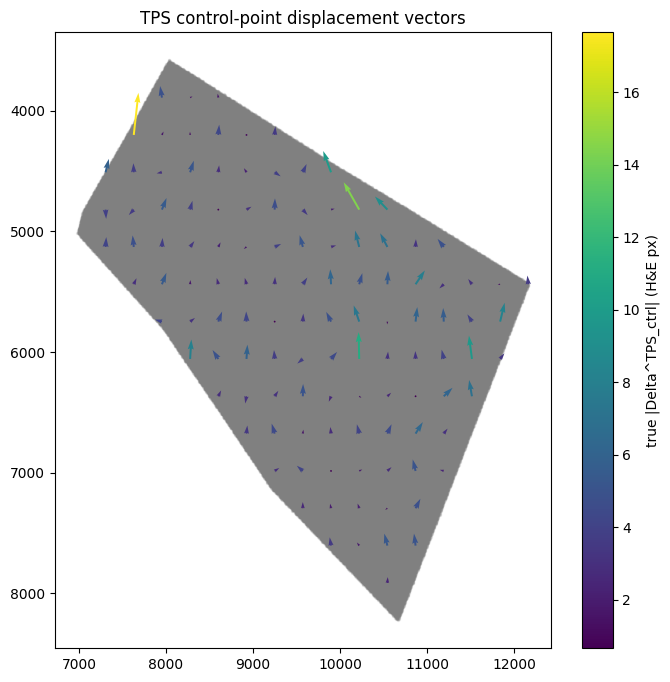

In [47]:


print("stopped because:", result.message)
T1_coords, dx_TPS, dy_TPS, dx_ctrl, dy_ctrl = apply_tps(result, K, P, Phi, Q, T0_maldi_coords)

corr_T0_full, _ = pearsonr(q0, s_T0)
corr_T1, _ = pearsonr(q0, project_to_msi(S_smooth, T1_coords))
print(f"correlation before TPS (T0, full slide): {corr_T0_full:.4f}   after TPS (T1, full slide): {corr_T1:.4f}")

# displacement magnitude over all MSI pixels
disp_mag = np.sqrt(dx_TPS**2 + dy_TPS**2)
plt.figure(figsize=(8, 8))
plt.scatter(T0_maldi_coords[:, 0], T0_maldi_coords[:, 1], c=disp_mag, s=4, cmap="magma")
plt.gca().invert_yaxis()
plt.colorbar(label="|Delta^TPS| (H&E px)")
plt.title(f"TPS displacement magnitude T-1 coords: r = {corr_T1:.4f}")
plt.show()

# control-point-level displacement vectors -- the actual optimized parameters.
# Arrows are drawn EXAGGERATED (scaled up by exaggeration) purely so they're
# visible against the tissue's thousands-of-units extent; color encodes the
# true (non-exaggerated) displacement magnitude.
ctrl_mag = np.sqrt(dx_ctrl**2 + dy_ctrl**2)
exaggeration = 20
plt.figure(figsize=(8, 8))
plt.scatter(T0_maldi_coords[:, 0], T0_maldi_coords[:, 1], s=2, alpha=0.15, c="gray")
q_plot = plt.quiver(
    control_points[:, 0], control_points[:, 1],
    dx_ctrl * exaggeration, dy_ctrl * exaggeration,
    ctrl_mag, cmap="viridis",
    angles="xy", scale_units="xy", scale=1,
    width=0.004,
)
plt.colorbar(q_plot, label="true |Delta^TPS_ctrl| (H&E px)")
plt.gca().invert_yaxis()
plt.title(f"TPS control-point displacement vectors")
plt.show()

In [48]:
T1_coords

array([[ 6984.43398034,  5008.04753561],
       [ 6990.81985132,  4988.37247448],
       [ 6990.88801014,  4994.90901279],
       ...,
       [12155.71612112,  5451.39804484],
       [12161.92638983,  5431.6478886 ],
       [12162.05026403,  5438.18253726]], shape=(269511, 2))

def tps_lambda_sweep(K, P, Phi, Q, T0_coords, S_smooth, q, d_msi, lambdas_tps,
                      n_subsample=65000, maxiter=100, random_state=0):
    """
    Compare TPS fits across a range of lambda_TPS values, to check whether
    the current lambda under-regularizes (patchy/overfit field) vs.
    producing a genuinely smooth broad correction. Uses the same random
    subsample for every lambda (fixed random_state) so the comparison
    isn't confounded by different random subsets, and evaluates the final
    correlation on the FULL dataset (not the subsample) for a fair
    apples-to-apples number across lambdas.
    """
    results = []
    for lam in lambdas_tps:
        res = optimize_tps(K, P, Phi, Q, T0_coords, S_smooth, q, d_msi,
                            lambda_tps=lam, maxiter=maxiter,
                            n_subsample=n_subsample, random_state=random_state)
        T1_lam, dx_lam, dy_lam, dx_ctrl_lam, dy_ctrl_lam = apply_tps(res, K, P, Phi, Q, T0_coords)
        corr_lam, _ = pearsonr(q, project_to_msi(S_smooth, T1_lam))
        results.append({"lambda": lam, "result": res, "dx": dx_lam, "dy": dy_lam, "corr": corr_lam})
        print(f"lambda={lam:.1e}   converged={res.success}   nit={res.nit}   corr(full)={corr_lam:.4f}")
    return results

lambdas_tps = [0.001, 0.05]
sweep_results = tps_lambda_sweep(K, P, Phi, Q, T0_maldi_coords, S_smooth, q0, d_MSI, lambdas_tps)

# displacement magnitude side by side, one panel per lambda
fig, axes = plt.subplots(1, len(sweep_results), figsize=(5 * len(sweep_results), 5))
for ax, res in zip(axes, sweep_results):
    disp_mag = np.sqrt(res["dx"]**2 + res["dy"]**2)
    sc = ax.scatter(T0_maldi_coords[:, 0], T0_maldi_coords[:, 1], c=disp_mag, s=2, cmap="magma")
    ax.invert_yaxis()
    ax.set_title(f"λ_TPS={res['lambda']:.0e}\ncorr={res['corr']:.4f}")
    fig.colorbar(sc, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

# correlation vs lambda, with T0's baseline for reference
plt.figure(figsize=(6, 4))
plt.semilogx([r["lambda"] for r in sweep_results], [r["corr"] for r in sweep_results], marker="o")
plt.axhline(corr0, color="gray", linestyle="--", label="corr0 (T0, no TPS)")
plt.xlabel("λ_TPS")
plt.ylabel("correlation (T1, full dataset)")
plt.legend()
plt.title("TPS correlation vs bending-energy weight")
plt.show()

In [49]:
import napari
from qtpy.QtWidgets import QWidget, QVBoxLayout, QHBoxLayout, QLabel, QSlider
from qtpy.QtCore import Qt

def _add_point_size_widget(viewer, points_layers, size_range=(1, 50)):
    """
    Dock widget with one slider per points layer, so each layer's point
    size can be adjusted independently. The built-in napari size slider
    only rescales points while they're selected / in add mode -- setting
    layer.size directly on the full array is what actually resizes
    already-plotted points.
    """
    panel = QWidget()
    layout = QVBoxLayout()
    panel.setLayout(layout)

    for pts_layer in points_layers:
        row = QHBoxLayout()
        label = QLabel(pts_layer.name)
        slider = QSlider(Qt.Horizontal)
        slider.setMinimum(size_range[0])
        slider.setMaximum(size_range[1])
        current = int(np.atleast_1d(pts_layer.size).ravel()[0]) if len(pts_layer.data) else size_range[0]
        slider.setValue(current)

        def make_callback(layer):
            def callback(value):
                layer.size = np.full(len(layer.data), value)
                layer.refresh()
            return callback

        slider.valueChanged.connect(make_callback(pts_layer))

        row.addWidget(label)
        row.addWidget(slider)
        layout.addLayout(row)

    viewer.window.add_dock_widget(panel, area="right", name="Point Sizes")
    return panel

def view_signals_on_he_napari(he_img, layers, point_size=6):
    """
    Napari viewer: full H&E image with one points layer per entry in
    `layers`, each colored by its own continuous value. Only non-zero
    points are plotted per layer. A "Point Sizes" dock widget on the
    right lets each layer's point size be adjusted independently.

    layers: list of dicts, each with keys:
        "name":      layer name (str)
        "coords_he": (N, 2) array of (x, y) H&E-space coordinates
        "values":    (N,) array of values, same length as coords_he
        "colormap":  (optional) napari colormap name, default "viridis"
    """
    viewer = napari.Viewer()
    viewer.add_image(he_img, name="H&E", rgb=True)

    points_layers = []
    for layer in layers:
        coords_he = layer["coords_he"]
        values = np.asarray(layer["values"])
        colormap = layer.get("colormap", "viridis")

        mask = values > 0
        sig_values = values[mask]
        points_yx = coords_he[:, ::-1]  # napari 2D layers use (row, col) = (y, x)
        sig_pts = points_yx[mask]

        pts_layer = viewer.add_points(
            sig_pts,
            name=layer["name"],
            features={"value": sig_values},
            face_color="value",
            face_colormap=colormap,
            size=point_size,
            border_width=0,
        )
        points_layers.append(pts_layer)

    _add_point_size_widget(viewer, points_layers)

    napari.run()
    return viewer

def get_mz_column(spot_feature_matrix, mz_labels, mz_value, mz_tol=0.0042):
    """Extract the intensity column for the m/z bin nearest mz_value."""
    idx = np.argmin(np.abs(mz_labels - mz_value))
    matched_mz = mz_labels[idx]
    if abs(matched_mz - mz_value) > mz_tol:
        print(f"Warning: nearest bin {matched_mz:.4f} is {abs(matched_mz-mz_value):.4f} away from requested {mz_value}")
    values = np.asarray(spot_feature_matrix[:, idx].todense()).ravel()
    return values, matched_mz

## Hepatocyte-only analysis

In [50]:
graphclust_path = '/home/kia/MALDI_Metabolomics/metabol_data/space_ranger_segmented_outputs/analysis/clustering/gene_expression_graphclust/clusters.csv'
graphclust_df = pd.read_csv(graphclust_path)
print(f"Loaded {len(graphclust_df)} cells, {graphclust_df['Cluster'].nunique()} graph clusters")
graphclust_df['Cluster'].unique()

Loaded 62098 cells, 12 graph clusters


array([ 6,  4,  1,  2,  7,  3,  9, 12,  5, 11,  8, 10])

7954 cells in clusters [6, 7]


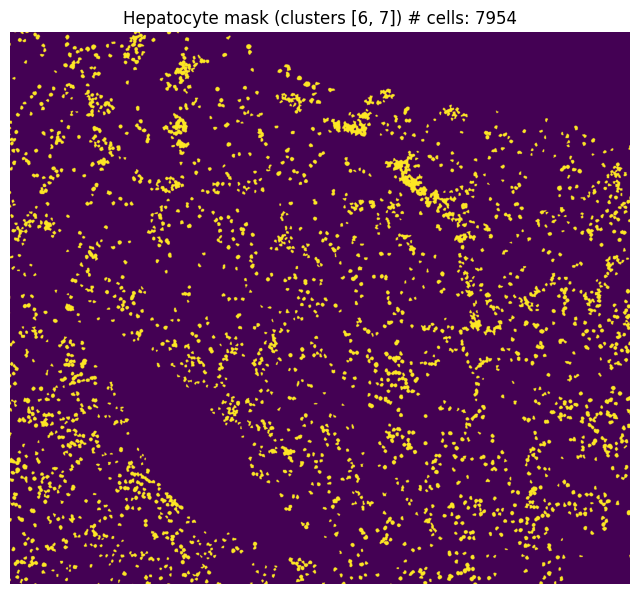

In [ ]:
import json

target_clusters = [1,2,3,4,6,7,9]

def load_hepatocyte_cells(geojson_path, target_clusters):
    """
    Per-cell polygons from the graph-cluster-annotated cell segmentation
    geojson, keeping only cells whose Space Ranger graph cluster is in
    target_clusters. Coordinates are in full-slide H&E pixel space.
    """
    with open(geojson_path) as f:
        data = json.load(f)

    polygons = []
    for feat in data["features"]:
        cluster_id = int(feat["properties"]["classification"]["name"].split("-")[1])
        if cluster_id in target_clusters:
            polygons.append(np.array(feat["geometry"]["coordinates"][0]))
    return polygons

hepatocyte_polygons = load_hepatocyte_cells(
    '/home/kia/MALDI_Metabolomics/metabol_data/space_ranger_segmented_outputs/graphclust_annotated_cell_segmentations.geojson',
    target_clusters,
)
print(f"{len(hepatocyte_polygons)} cells in clusters {target_clusters}")
def build_hepatocyte_mask(polygons, crop_shape, x_min, y_min):
    """Rasterize hepatocyte-cluster cell polygons into a binary mask on
    the cropped H&E region -- 1 inside a matching cell, 0 elsewhere."""
    mask = np.zeros(crop_shape[:2], dtype=np.uint8)
    for poly in polygons:
        local_poly = (poly - [x_min, y_min]).astype(np.int32)
        cv2.fillPoly(mask, [local_poly], 1)
    return mask.astype(np.float32)

hepatocyte_mask_crop = build_hepatocyte_mask(hepatocyte_polygons, cropped_img.shape, x_min, y_min)

# embed into full-H&E-sized canvas, matching the convention used for other masks
hepatocyte_mask = np.zeros(he_img.shape[:2], dtype=np.float32)
hepatocyte_mask[y_min:y_max, x_min:x_max] = hepatocyte_mask_crop

plt.figure(figsize=(8, 8))
plt.imshow(hepatocyte_mask_crop)
plt.title(f"Hepatocyte mask (clusters {target_clusters}) # cells: {len(hepatocyte_polygons)}")
plt.axis("off")
plt.show()


In [52]:
from sklearn.neighbors import NearestNeighbors

# get the nearest neighbors of the T0_maldi_coords and the distance between these points
neigh = NearestNeighbors(n_neighbors=2)
neigh.fit(T0_maldi_coords)
distances, _ = neigh.kneighbors(T0_maldi_coords)
d_MSI = np.median(distances[:, 1])

# Wendland support radius (paper Sec. 2.2): rho = (sqrt(2)/2) * median(...)
# -- no safety-factor margin, unlike the old paper's (1+eta) version
rho = d_MSI / np.sqrt(2)
h = rho ** 2
r = d_MSI  # kept for any downstream reference to the old name

In [53]:
from typing import Any, Dict

def run_pipeline_for_mask(
    mask: np.ndarray,
    M: np.ndarray,
    h: float,
    T0_maldi_coords: np.ndarray,
    he_landmarks: np.ndarray,
    X_scaled: np.ndarray,
    p: int,
    K: np.ndarray,
    P: np.ndarray,
    Phi: np.ndarray,
    Q: np.ndarray,
    d_MSI: float,
    mask_name: str = "mask",
    lambda_tps: float = 0.2,
    tps_maxiter: int = 100,
    tps_n_subsample: int = 100000,
) -> Dict[str, Any]:
    """
    Runs the full metafeature-learning-through-TPS-optimization pipeline
    (paper Secs. 2.1-2.6) for an arbitrary binary anatomical mask.

    Every input the pipeline needs is passed explicitly (no reliance on
    notebook globals), so this function behaves the same regardless of
    what else has been run in the notebook. k_i/d_i/splits are recomputed
    fresh from he_landmarks/T0_maldi_coords on every call rather than
    reused from global state, since fiducial ownership must stay
    consistent with whichever T0 was actually used to produce
    T0_maldi_coords.

    Parameters
    ----------
    mask : np.ndarray
        Binary anatomical mask on the full H&E canvas (paper Sec. 2.1
        S_HE), e.g. hepatocyte_mask or nuclei_mask.
    M : np.ndarray
        Valid-pixel mask of the H&E image (paper Sec. 2.1), same shape
        as mask.
    h : float
        Wendland kernel support parameter (rho ** 2), from the initial
        Wendland-radius cell.
    T0_maldi_coords : np.ndarray, shape (n, 2)
        MSI spot coordinates mapped into H&E space via T0.
    he_landmarks : np.ndarray, shape (K, 2)
        H&E fiducial coordinates h_1, ..., h_K (paper Sec. 2.4).
    X_scaled : np.ndarray, shape (n, p)
        Standardized, zero-variance-filtered MSI feature matrix (paper
        Sec. 2.3), from preprocess_features.
    p : int
        Number of retained MSI features (X_scaled.shape[1]).
    K, P, Phi, Q : np.ndarray
        TPS basis matrices from build_tps_basis, shared across masks
        since they only depend on T0_maldi_coords and the control grid.
    d_MSI : float
        Median native MSI pixel spacing, used for the TPS displacement
        cap and optimizer step size.
    mask_name : str, default "mask"
        Label stored in the returned dict, for titling plots.
    lambda_tps : float, default 0.1
        TPS bending-energy regularization weight (paper Sec. 2.3).
    tps_maxiter : int, default 100
        Max L-BFGS-B iterations for the TPS fit.
    tps_n_subsample : int, default 65000
        Number of MSI pixels to subsample when evaluating the TPS
        objective during optimization (Sec. 2.3's optimize_tps).

    Returns
    -------
    Dict[str, Any]
        "name": mask_name.
        "S_smooth": smoothed mask field f(z) (Sec. 2.1).
        "s_T0": anatomical target signal sampled at T0_maldi_coords.
        "r_min", "r_max", "radius_candidates": peri-fiducial radius
            search (Sec. 2.4).
        "C_values", "C_max", "r_hat": held-out radius selection (Sec. 2.5).
        "w_hat0", "q0", "corr0": final metafeature fit (Sec. 2.3,
            restricted to I_r_hat).
        "tps_result": scipy OptimizeResult from optimize_tps.
        "T1_coords", "dx_TPS", "dy_TPS", "dx_ctrl", "dy_ctrl": fitted TPS
            displacement (Sec. 2.6).
        "corr_T0_full", "corr_T1": full-slide correlation before/after
            TPS.
    """
    S_smooth_m = smooth_mask_normalized(mask, M, h)
    s_T0_m = project_to_msi(S_smooth_m, T0_maldi_coords)

    k_i, d_i = assign_to_fiducials(T0_maldi_coords, he_landmarks)
    splits = spatially_balanced_splits(he_landmarks, k_i, B=10)

    r_min_m = minimum_candidate_radius(splits, k_i, d_i, s_T0_m, p)
    r_max_m = d_i.max()
    between_m = d_i[(d_i > r_min_m) & (d_i < r_max_m)]
    quantile_fracs = np.linspace(0, 1, 10)[1:-1]
    intermediate_radii_m = np.quantile(between_m, quantile_fracs)
    radius_candidates_m = np.unique(np.concatenate([[r_min_m], intermediate_radii_m, [r_max_m]]))

    C_values_m = np.array([
        held_out_radius_score(r, splits, k_i, d_i, X_scaled, s_T0_m) for r in radius_candidates_m
    ])
    C_max_m = C_values_m.max()
    r_hat_m = radius_candidates_m[C_values_m >= C_max_m - 0.01].max()

    #### putting in a bug just as a test to see if it works # changing r_hat_m
    #r_hat_m = 200.0
    #### ---------------------------

    I_r_hat_m = np.where(d_i <= r_hat_m)[0]
    w_hat0_m = fit_ridge_metafeature(X_scaled, s_T0_m, I_r_hat_m, lam=0.05)
    q0_m = X_scaled @ w_hat0_m
    corr0_m, _ = pearsonr(q0_m[I_r_hat_m], s_T0_m[I_r_hat_m])

    tps_result_m = optimize_tps(
        K, P, Phi, Q, T0_maldi_coords, S_smooth_m, q0_m, d_MSI,
        lambda_tps=lambda_tps, maxiter=tps_maxiter, n_subsample=tps_n_subsample,
    )
    T1_coords_m, dx_m, dy_m, dx_ctrl_m, dy_ctrl_m = apply_tps(tps_result_m, K, P, Phi, Q, T0_maldi_coords)
    corr_T0_full_m, _ = pearsonr(q0_m, s_T0_m)
    corr_T1_m, _ = pearsonr(q0_m, project_to_msi(S_smooth_m, T1_coords_m))

    return {
        "name": mask_name, "S_smooth": S_smooth_m, "s_T0": s_T0_m,
        "r_min": r_min_m, "r_max": r_max_m, "radius_candidates": radius_candidates_m,
        "C_values": C_values_m, "C_max": C_max_m, "r_hat": r_hat_m, "d_i": d_i,
        "w_hat0": w_hat0_m, "q0": q0_m, "corr0": corr0_m,
        "tps_result": tps_result_m, "T1_coords": T1_coords_m,
        "dx_TPS": dx_m, "dy_TPS": dy_m, "dx_ctrl": dx_ctrl_m, "dy_ctrl": dy_ctrl_m,
        "corr_T0_full": corr_T0_full_m, "corr_T1": corr_T1_m,
    }

hepatocyte_results = run_pipeline_for_mask(
    hepatocyte_mask, M, h, T0_maldi_coords, he_landmarks, X_scaled, p, K, P, Phi, Q, d_MSI,
    mask_name="hepatocyte",
)
print(f"hepatocyte: r_hat={hepatocyte_results['r_hat']:.1f}  "
      f"corr0={hepatocyte_results['corr0']:.4f}  "
      f"corr_T0_full={hepatocyte_results['corr_T0_full']:.4f}  "
      f"corr_T1={hepatocyte_results['corr_T1']:.4f}")


hepatocyte: r_hat=606.8  corr0=0.1870  corr_T0_full=0.1642  corr_T1=0.1724


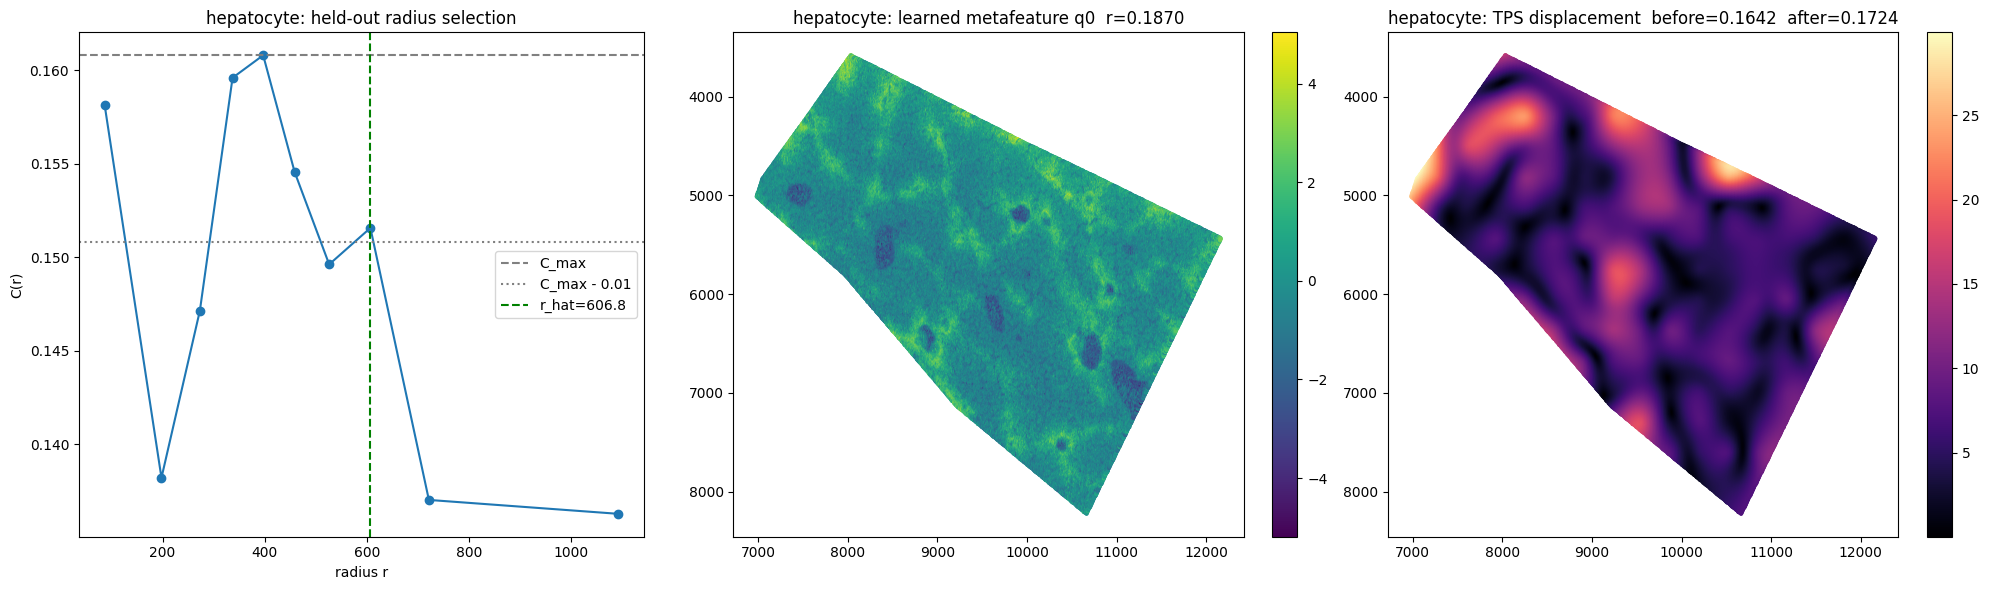

In [54]:
res = hepatocyte_results
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].plot(res["radius_candidates"], res["C_values"], marker="o")
axes[0].axhline(res["C_max"], color="gray", linestyle="--", label="C_max")
axes[0].axhline(res["C_max"] - 0.01, color="gray", linestyle=":", label="C_max - 0.01")
axes[0].axvline(res["r_hat"], color="green", linestyle="--", label=f"r_hat={res['r_hat']:.1f}")
axes[0].set_xlabel("radius r"); axes[0].set_ylabel("C(r)")
axes[0].set_title(f"{res['name']}: held-out radius selection"); axes[0].legend()

sc1 = axes[1].scatter(T0_maldi_coords[:, 0], T0_maldi_coords[:, 1], c=res["q0"], s=4, cmap="viridis")
axes[1].invert_yaxis()
axes[1].set_title(f"{res['name']}: learned metafeature q0  r={res['corr0']:.4f}")
fig.colorbar(sc1, ax=axes[1], fraction=0.046)

disp_mag = np.sqrt(res["dx_TPS"]**2 + res["dy_TPS"]**2)
sc2 = axes[2].scatter(T0_maldi_coords[:, 0], T0_maldi_coords[:, 1], c=disp_mag, s=4, cmap="magma")
axes[2].invert_yaxis()
axes[2].set_title(f"{res['name']}: TPS displacement  before={res['corr_T0_full']:.4f}  after={res['corr_T1']:.4f}")
fig.colorbar(sc2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()


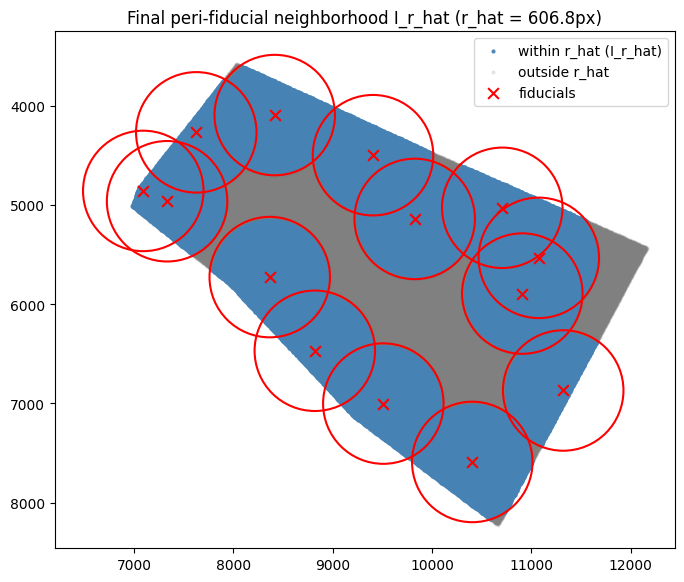

In [55]:
# QC 7: final peri-fiducial neighborhood I_r_hat -- circles of radius
# r_hat drawn around every fiducial, spots inside I_r_hat opaque, spots
# outside faded

in_radius = res["d_i"] <= res["r_hat"]

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(T0_maldi_coords[in_radius, 0], T0_maldi_coords[in_radius, 1],
           c="steelblue", s=4, alpha=0.9, label="within r_hat (I_r_hat)")
ax.scatter(T0_maldi_coords[~in_radius, 0], T0_maldi_coords[~in_radius, 1],
           c="gray", s=4, alpha=0.15, label="outside r_hat")

for landmark in he_landmarks:
    ax.add_patch(plt.Circle(landmark, res["r_hat"], fill=False, edgecolor="red", linewidth=1.5))
ax.scatter(he_landmarks[:, 0], he_landmarks[:, 1], c="red", marker="x", s=60, label="fiducials")

ax.set_aspect("equal")
ax.invert_yaxis()
ax.legend()
ax.set_title(f"Final peri-fiducial neighborhood I_r_hat (r_hat = {res['r_hat']:.1f}px)")
plt.show()

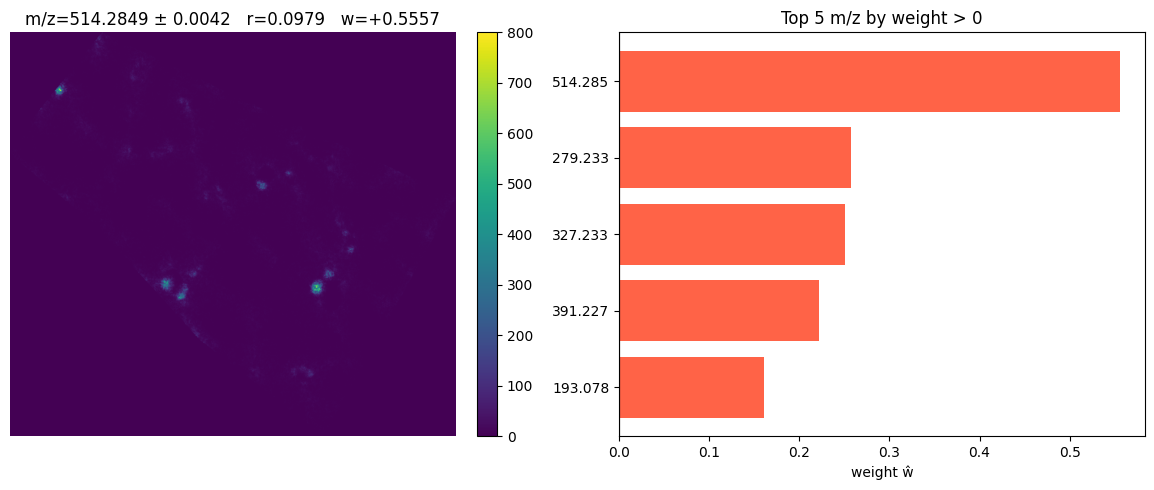

array([163,  84, 103, 118,  50])

In [56]:
plot_top_weighted_ion_maps( X_scaled= X_scaled,  
                           w_hat= hepatocyte_results["w_hat0"],  
                           s_scaled= hepatocyte_results["s_T0"],  
                           mz_labels= mz_labels,  parser= maldi_parser,  
                           top_n= 5,  
                           mz_tol= 0.0042)


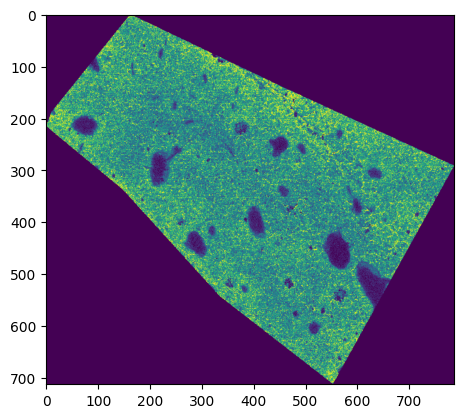

In [57]:
ion_mat = getionimage(maldi_parser,mz_value=279.233, tol=.0042)
plt.imshow(ion_mat, vmin=np.percentile(ion_mat,1), vmax=np.percentile(ion_mat, 99))
#plt.imshow(ion_mat)

In [58]:
mz_value = 279.233
disp_mag = np.sqrt(res["dx_TPS"]**2 + res["dy_TPS"]**2)
mz_values, matched_mz = get_mz_column(spot_feature_matrix, mz_labels, mz_value)
mz_lo, mz_hi = np.percentile(mz_values, [1, 99])
mz_values_clipped = np.where(mz_values > 0, np.clip(mz_values, mz_lo, mz_hi), 0)
#T1_maldi_coords_df = pd.read_csv('/home/kia/MALDI_Metabolomics/notebooks/T1_finescale.csv')
#T1_maldi_coords = T1_maldi_coords_df[['X', 'Y']].to_numpy()
viewer = view_signals_on_he_napari(
    he_img,
    layers=[
        {"name": "tps_displacement_magnitude", "coords_he": res['T1_coords'], "values": disp_mag, "colormap": "magma"},
        {"name": "q0", "coords_he": res['T1_coords'], "values": res['q0'], "colormap": "viridis"},
        {"name": "s_T0", "coords_he": res['T1_coords'], "values": res['s_T0'], "colormap": "magma"},
        {"name": f"mz_{matched_mz:.4f}", "coords_he": res['T1_coords'], "values": mz_values_clipped, "colormap": "viridis"},
      ],
    point_size=6,
)

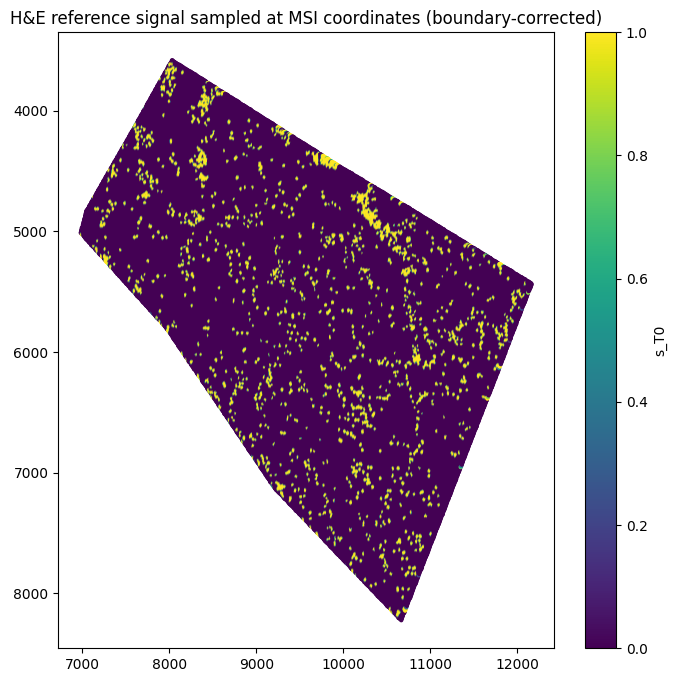

In [ ]:
plt.figure(figsize=(8, 8))
plt.scatter(T0_maldi_coords[:, 0], T0_maldi_coords[:, 1], c=res['s_T0'], s=4, cmap="viridis")
plt.gca().invert_yaxis()
plt.colorbar(label="s_T0")
plt.title("H&E reference signal sampled at MSI coordinates (boundary-corrected)")
#plt.savefig('Nuclei_reference_mask_S(HE_nuclei).png')
plt.show()